<div style="background-color:#2C5282; padding:15px; border-radius:6px; text-align:center; color:white; font-size:32px; font-weight:bold;">
Customer Engagement & Product Utilization Analytics for Retention Strategy
</div>

#### ---------------------------------------------------------------------------------------------------------------------------------------------------------

<img src="bank_ai_dashboard.png" width="1200"/>

#### ---------------------------------------------------------------------------------------------------------------------------------------------------------

<div style="
    border:2px dashed #B0B0B0;
    padding:20px 25px;
    margin:20px 0;
    background-color:#F9F9F9;
">
    
<b>Problem Statement:</b>  
Despite having data on customer engagement and product usage, banks often lack:

• Quantitative insight into which behaviors drive retention

• Clarity on whether product depth reduces churn

• Evidence on whether high balances alone ensure loyalty
<br><br>

<b>Project Overview:</b>                             
Banks increasingly recognize that customer behavior and engagement—not just demographics—determine long-term retention. Customers may appear financially strong (high balance or salary) but still churn due to:


• Low engagement

• Limited product adoption

• Weak relationship depth with the bank    
<br><br>
<b>Project Benefits:</b>                                    
Understanding how customers use banking products and services is essential to designing:


• Cross-sell strategies

• Loyalty programs

• Engagement-driven retention initiatives    
<br><br>
<b>Deliverables:</b> 

• Research paper (EDA, insights, recommendations)

• Streamlit dashboard (live analytics)

• Executive summary for government stakeholders
</div>

---

<div style="
    border:2px dashed #B0B0B0;
    padding:22px 28px;
    margin:25px 0;
    background-color:#FAFAFA;
">

<h3 style="margin-top:0;">📋 Data Columns Description</h3>

<p>Here is a brief description of each column used in the Customer Engagement & Product Utilization Analytics for Retention Strategy :</p
                                                                                                                            

1. CustomerId – Unique identifier assigned to each customer.  

2. Surname – Customer surname.  

3. CreditScore – Customer creditworthiness score.  

4. Geography – Customer location (France, Spain, Germany).  

5. Gender – Gender of the customer.  

6. Age – Age of the customer.  

7. Tenure – Number of years with the bank.  

8. Balance – Account balance maintained by the customer.  

9. NumOfProducts – Number of bank products used by the customer.  

10. HasCrCard – Indicates whether the customer owns a credit card.  

11. IsActiveMember – Indicates whether the customer is an active bank member.  

12. EstimatedSalary – Estimated annual salary of the customer.  

13. Exited – Target variable representing customer churn status (1 = Churned, 0 = Retained).                                                                                                                                       
                                                                                        

<div style="
    border:2px dashed #B0B0B0;
    padding:20px 28px;
    margin:25px 0;
    background-color:#FAFAFA;
">

<h3 style="margin-top:0;">📌 Task</h3>

<p>
• Evaluate the relationship between engagement and churn
    
• Measure retention impact of product count and product mix

• Identify disengaged yet high-value customers

• Support engagement-driven retention strategies

• Improve product bundling decisions

• Reduce silent churn among premium customers
</p>

</div>

<hr style="border-top:2px dashed #9A9A9A; margin:30px 0;">

<h1>  Import Necessary Libraries</h1> 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix,roc_curve,auc,precision_recall_curve

<h1> Load the Dataset</h1>

In [2]:
df = pd.read_csv("European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.tail()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,2025,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


<h1> Data Preprocessing</h1>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
df["HasCrCard"].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

In [8]:
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

In [9]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [10]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


<h1> Feature Engineering & Exploratory Data Analysis</h1>

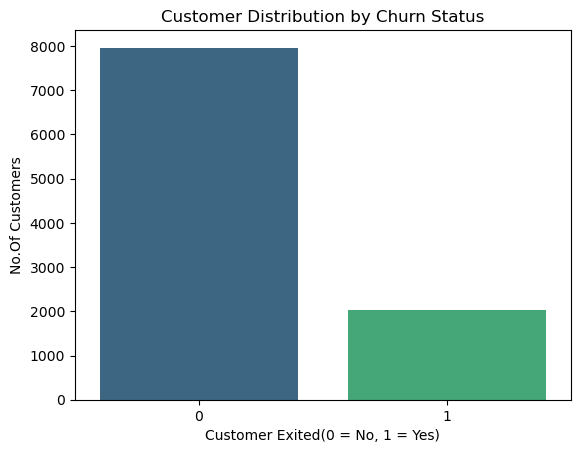

In [11]:
sns.countplot(data = df,x='Exited', hue='Exited', palette='viridis', legend=False)
plt.title("Customer Distribution by Churn Status")
plt.xlabel("Customer Exited(0 = No, 1 = Yes)")
plt.ylabel("No.Of Customers")
plt.show()

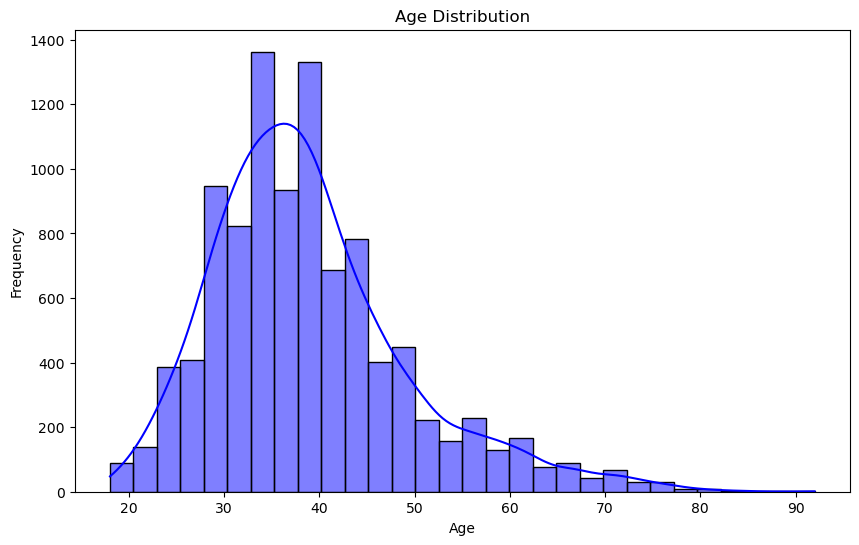

In [12]:
plt.figure(figsize=(10, 6))       # Sets the plot size to 10x6 inches
sns.histplot(df['Age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
# Adds a title, x-axis label, and y-axis label.

plt.show()         # Display the plot

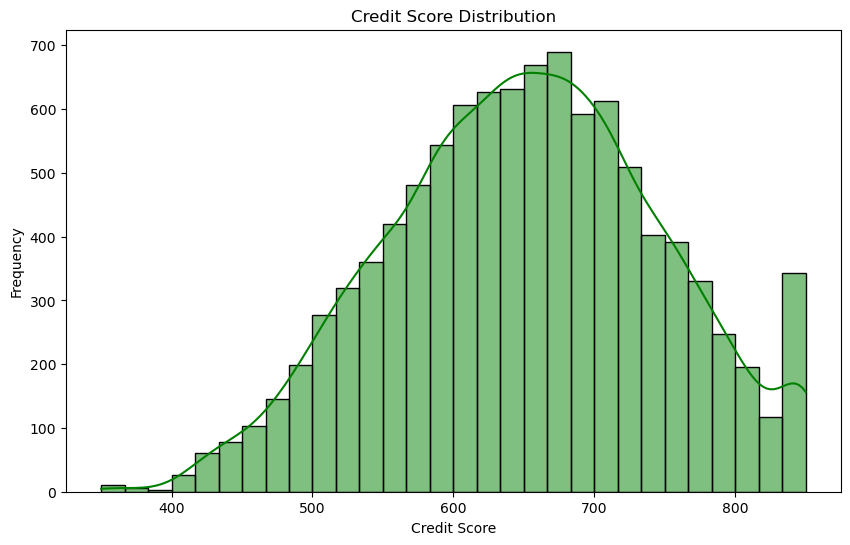

In [13]:
plt.figure(figsize=(10, 6))       # Sets the plot size to 10x6 inches
sns.histplot(df['CreditScore'], bins=30, kde=True, color='green')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
# Adds a title, x-axis label, and y-axis label.

plt.show()         # Display the plot

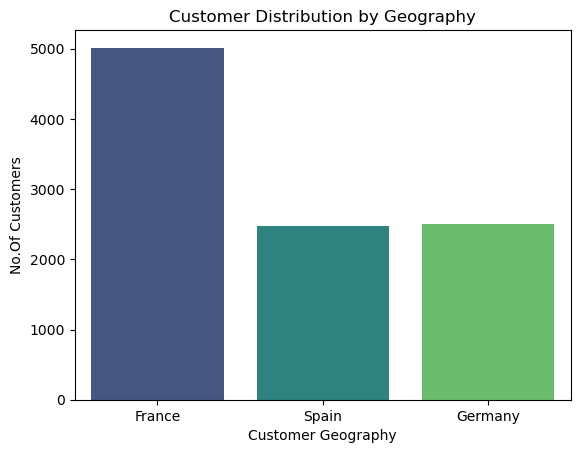

In [14]:
sns.countplot(data = df,x='Geography', hue='Geography', palette='viridis', legend=False)
plt.title("Customer Distribution by Geography")
plt.xlabel("Customer Geography")
plt.ylabel("No.Of Customers")
plt.show()

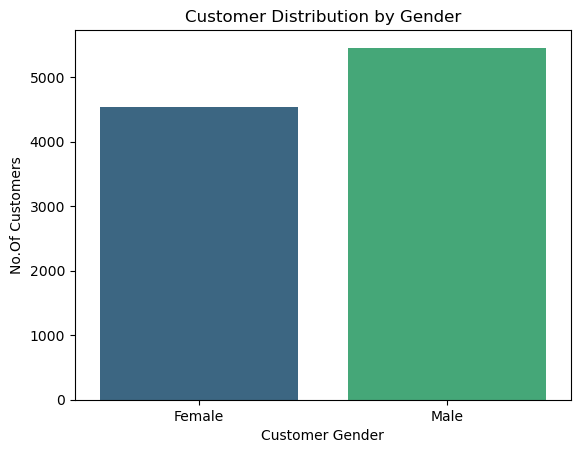

In [15]:
sns.countplot(data = df,x='Gender', hue='Gender', palette='viridis', legend=False)
plt.title("Customer Distribution by Gender")
plt.xlabel("Customer Gender")
plt.ylabel("No.Of Customers")
plt.show()

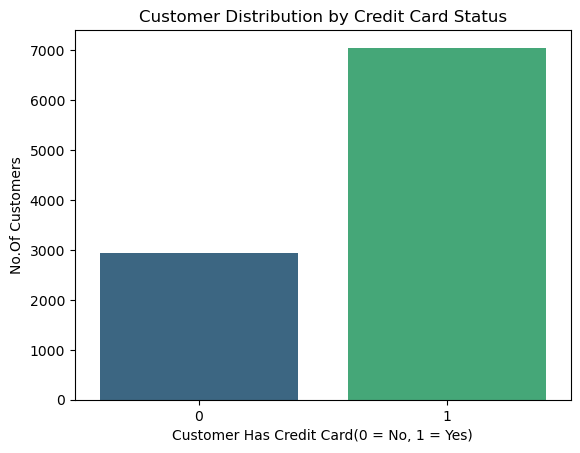

In [16]:
sns.countplot(data = df,x='HasCrCard', hue='HasCrCard', palette='viridis', legend=False)
plt.title("Customer Distribution by Credit Card Status")
plt.xlabel("Customer Has Credit Card(0 = No, 1 = Yes)")
plt.ylabel("No.Of Customers")
plt.show()

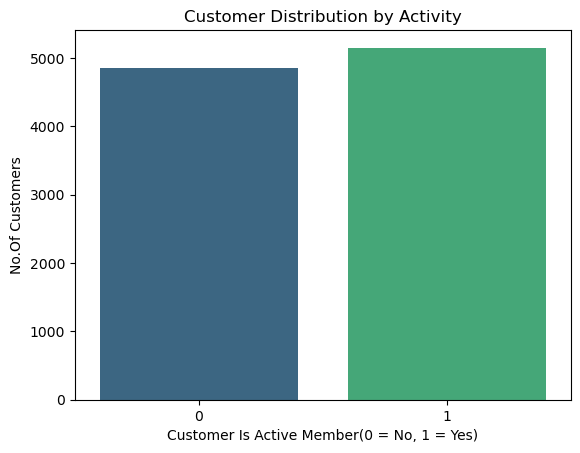

In [17]:
sns.countplot(data = df,x='IsActiveMember', hue='IsActiveMember', palette='viridis', legend=False)
plt.title("Customer Distribution by Activity")
plt.xlabel("Customer Is Active Member(0 = No, 1 = Yes)")
plt.ylabel("No.Of Customers")
plt.show()

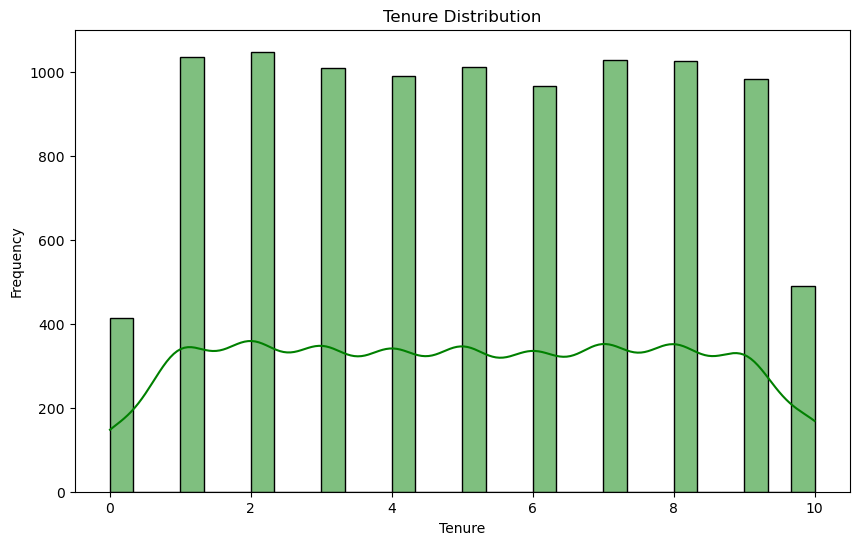

In [18]:
plt.figure(figsize=(10, 6))       # Sets the plot size to 10x6 inches
sns.histplot(df['Tenure'], bins=30, kde=True, color='green')
plt.title('Tenure Distribution')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
# Adds a title, x-axis label, and y-axis label.

plt.show()         # Display the plot

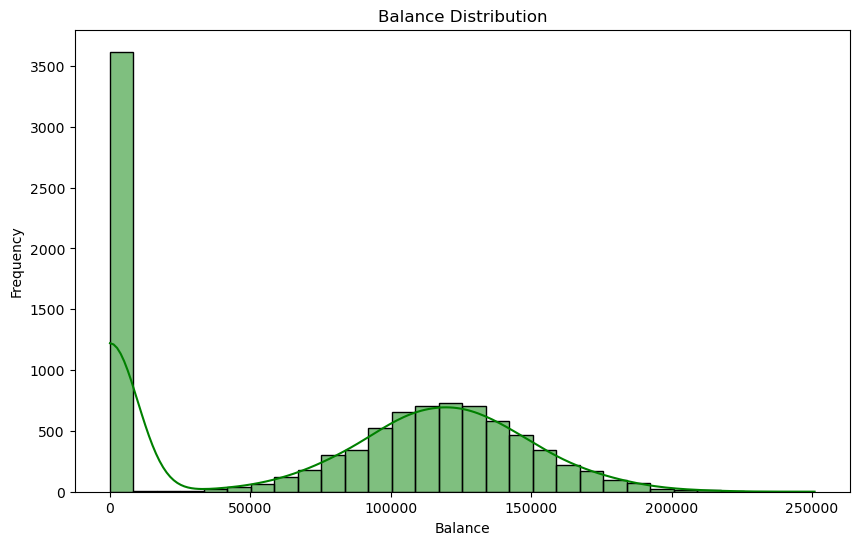

In [19]:
plt.figure(figsize=(10, 6))       # Sets the plot size to 10x6 inches
sns.histplot(df['Balance'], bins=30, kde=True, color='green')
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
# Adds a title, x-axis label, and y-axis label.

plt.show()         # Display the plot

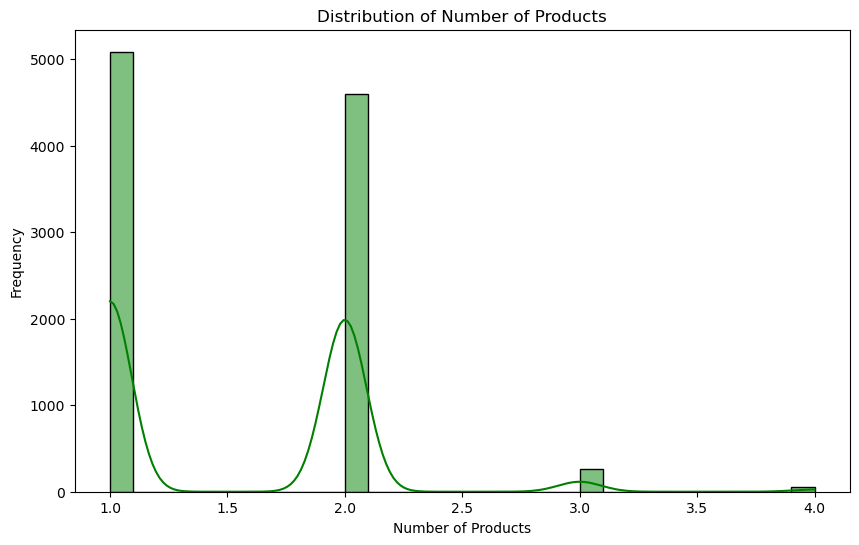

In [20]:
plt.figure(figsize=(10, 6))       # Sets the plot size to 10x6 inches
sns.histplot(df['NumOfProducts'], bins=30, kde=True, color='green')
plt.title('Distribution of Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Frequency')
# Adds a title, x-axis label, and y-axis label.

plt.show()         # Display the plot

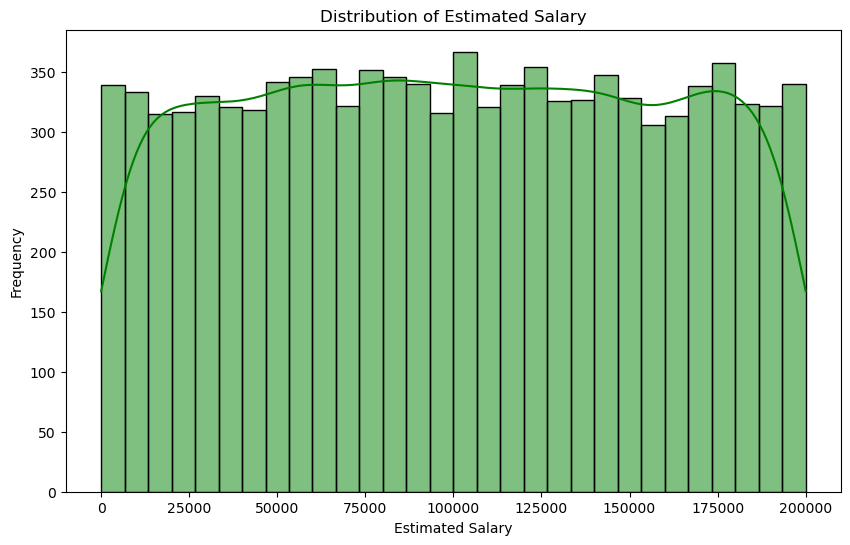

In [21]:
plt.figure(figsize=(10, 6))       # Sets the plot size to 10x6 inches
sns.histplot(df['EstimatedSalary'], bins=30, kde=True, color='green')
plt.title('Distribution of Estimated Salary')
plt.xlabel('Estimated Salary')
plt.ylabel('Frequency')
# Adds a title, x-axis label, and y-axis label.

plt.show()         # Display the plot

In [22]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

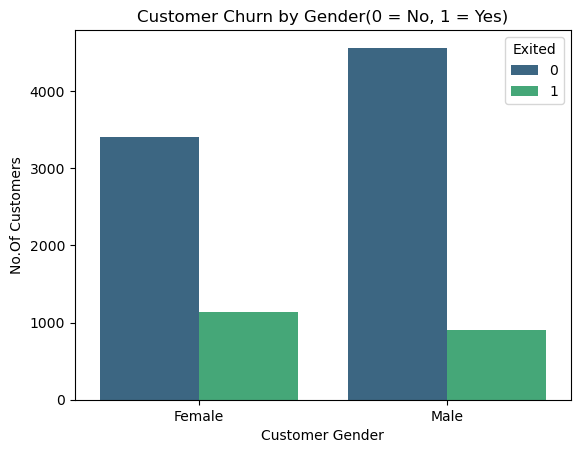

In [23]:
sns.countplot(data = df,x='Gender', hue='Exited', palette='viridis', legend=True)
plt.title("Customer Churn by Gender(0 = No, 1 = Yes)")
plt.xlabel("Customer Gender")
plt.ylabel("No.Of Customers")
plt.show()

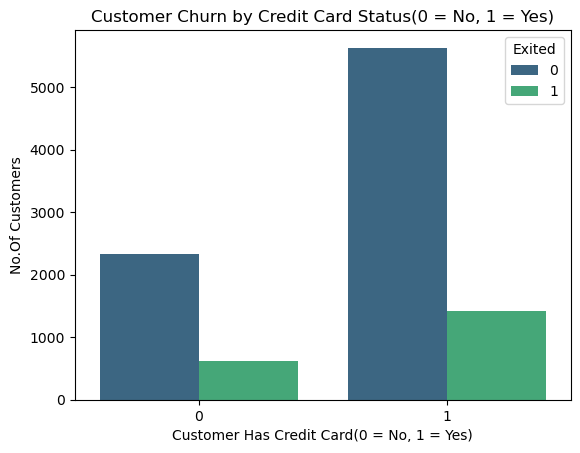

In [24]:
sns.countplot(data = df,x='HasCrCard', hue='Exited', palette='viridis', legend=True)
plt.title("Customer Churn by Credit Card Status(0 = No, 1 = Yes)")
plt.xlabel("Customer Has Credit Card(0 = No, 1 = Yes)")
plt.ylabel("No.Of Customers")
plt.show()

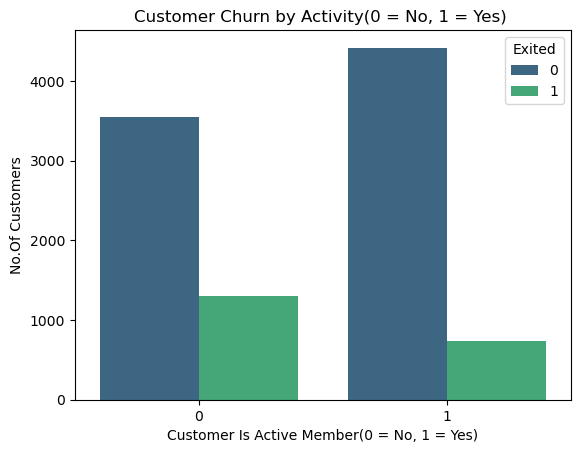

In [124]:
sns.countplot(data = df,x='IsActiveMember', hue='Exited', palette='viridis', legend=True)
plt.title("Customer Churn by Activity(0 = No, 1 = Yes) ")
plt.xlabel("Customer Is Active Member(0 = No, 1 = Yes)")
plt.ylabel("No.Of Customers")
plt.show()

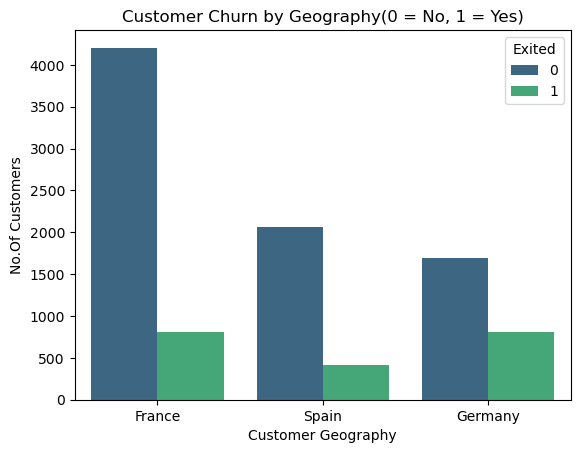

In [26]:
sns.countplot(data = df,x='Geography', hue='Exited', palette='viridis', legend=True)
plt.title("Customer Churn by Geography(0 = No, 1 = Yes)")
plt.xlabel("Customer Geography")
plt.ylabel("No.Of Customers")
plt.show()

C:\Users\conne\AppData\Local\Temp\ipykernel_25016\3808383772.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup2')['Exited']


           AgeGroup2  ChurnRate
0  Younger Customers  13.689948
1    Older Customers  45.333965


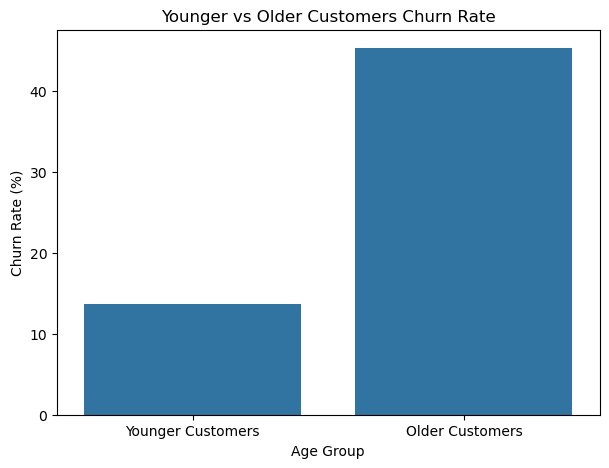

In [27]:
# Create 2 Age Groups

df['AgeGroup2'] = pd.cut(
    df['Age'],
    bins=[0, 45, 100],
    labels=['Younger Customers', 'Older Customers']
)

# Calculate churn rate
age_group_churn = (
    df.groupby('AgeGroup2')['Exited']
    .mean()
    .reset_index(name='ChurnRate')
)

# Convert to percentage
age_group_churn['ChurnRate'] = (
    age_group_churn['ChurnRate'] * 100
)

print(age_group_churn)

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.barplot(
    data=age_group_churn,
    x='AgeGroup2',
    y='ChurnRate'
)

plt.title("Younger vs Older Customers Churn Rate")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

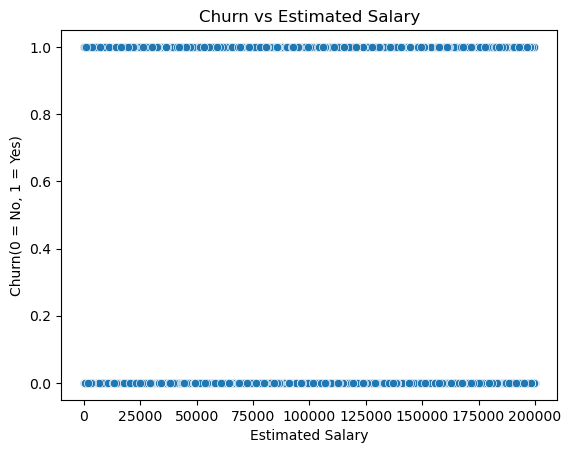

In [28]:
sns.scatterplot(x='EstimatedSalary',y='Exited',data = df)
plt.title("Churn vs Estimated Salary")
plt.xlabel("Estimated Salary")
plt.ylabel('Churn(0 = No, 1 = Yes)')
plt.show()

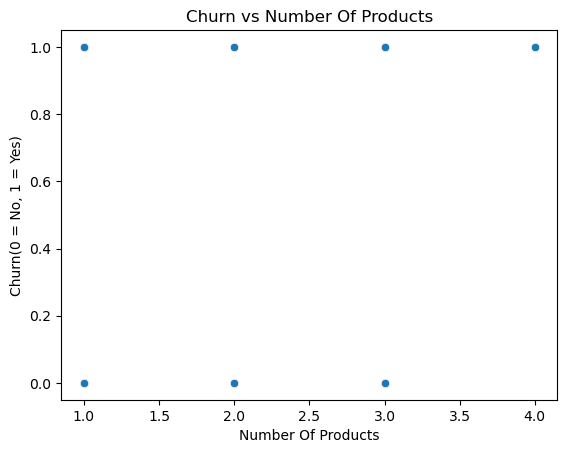

In [29]:
sns.scatterplot(x='NumOfProducts',y='Exited',data = df)
plt.title("Churn vs Number Of Products")
plt.xlabel("Number Of Products")
plt.ylabel('Churn(0 = No, 1 = Yes)')
plt.show()

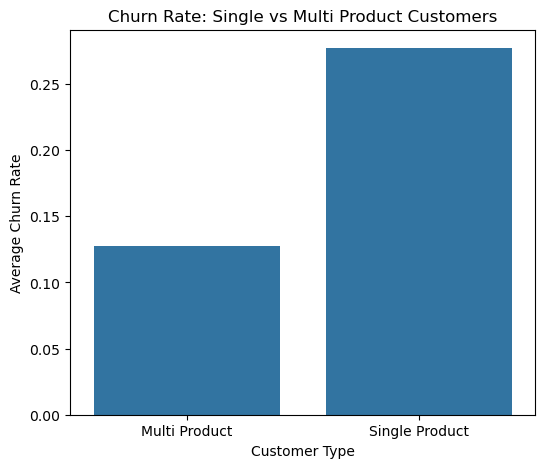

In [30]:
# Create customer type based on number of products
df['ProductCategory'] = df['NumOfProducts'].apply(
    lambda x: 'Single Product' if x == 1 else 'Multi Product'
)

# Calculate churn rate
product_churn = (
    df.groupby('ProductCategory')['Exited']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(6,5))

sns.barplot(
    data=product_churn,
    x='ProductCategory',
    y='Exited'
)

plt.title("Churn Rate: Single vs Multi Product Customers")
plt.xlabel("Customer Type")
plt.ylabel("Average Churn Rate")

plt.show()

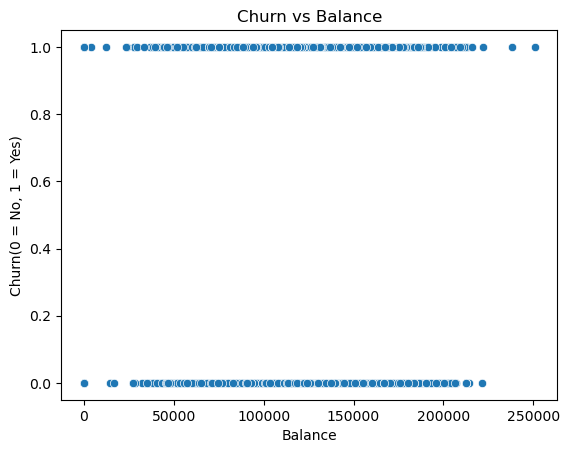

In [31]:
sns.scatterplot(x='Balance',y='Exited',data = df)
plt.title("Churn vs Balance")
plt.xlabel("Balance")
plt.ylabel('Churn(0 = No, 1 = Yes)')
plt.show()

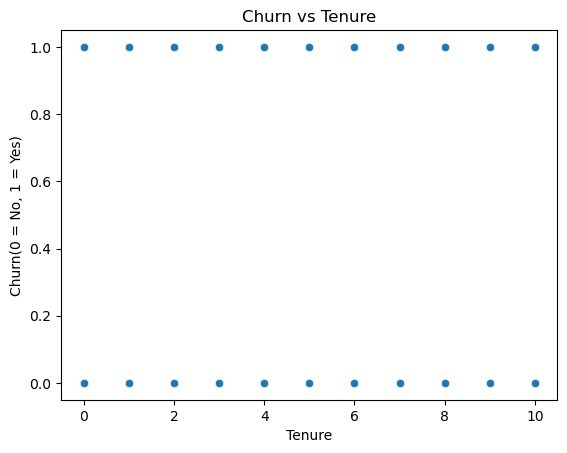

In [32]:
sns.scatterplot(x='Tenure',y='Exited',data = df)
plt.title("Churn vs Tenure")
plt.xlabel("Tenure")
plt.ylabel('Churn(0 = No, 1 = Yes)')
plt.show()

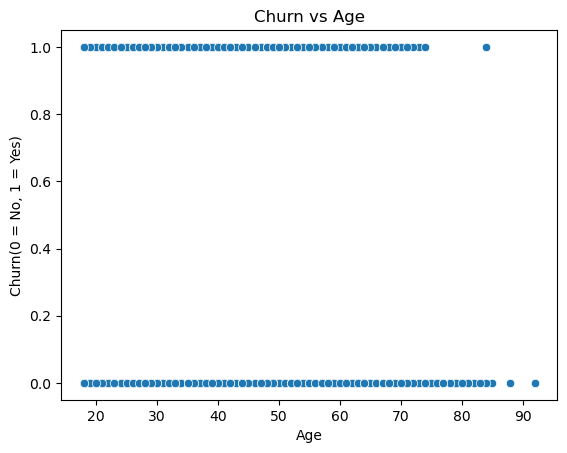

In [33]:
sns.scatterplot(x='Age',y='Exited',data = df)
plt.title("Churn vs Age")
plt.xlabel("Age")
plt.ylabel('Churn(0 = No, 1 = Yes)')
plt.show()

**Active engaged customers:**

In [34]:
active_engaged = df[
    (df['IsActiveMember'] == 1) &
    (df['Balance'] >= 50000) &
    (df['Tenure'] >= 7)
]

active_engaged.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup2,ProductCategory
31,2025,15706552,Odinakachukwu,533,France,Male,36,7,85311.70,1,0,1,156731.91,0,Younger Customers,Single Product
37,2025,15729599,Lorenzo,804,Spain,Male,33,7,76548.60,1,0,1,98453.45,0,Younger Customers,Single Product
46,2025,15602280,Martin,829,Germany,Female,27,9,112045.67,1,1,1,119708.21,1,Younger Customers,Single Product
47,2025,15771573,Okagbue,637,Germany,Female,39,9,137843.80,1,1,1,117622.80,1,Younger Customers,Single Product
63,2025,15751208,Pirozzi,684,Spain,Male,56,8,78707.16,1,1,1,99398.36,0,Older Customers,Single Product


**Inactive disengaged customers:**

In [35]:
inactive_disengaged = df[
    (df['IsActiveMember'] == 0) &
    (df['Balance'] < 50000) &
    (df['Tenure'] < 7)
]

inactive_disengaged.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup2,ProductCategory
3,2025,15701354,Boni,699,France,Female,39,1,0.0,2,0,0,93826.63,0,Younger Customers,Multi Product
11,2025,15737173,Andrews,497,Spain,Male,24,3,0.0,2,1,0,76390.01,0,Younger Customers,Multi Product
13,2025,15691483,Chin,549,France,Female,25,5,0.0,2,0,0,190857.79,0,Younger Customers,Multi Product
18,2025,15661507,Muldrow,587,Spain,Male,45,6,0.0,1,0,0,158684.81,0,Younger Customers,Single Product
22,2025,15699309,Gerasimov,510,Spain,Female,38,4,0.0,1,1,0,118913.53,1,Younger Customers,Single Product


**Active but low-product customers:**

In [36]:
active_low_product = df[
    (df['IsActiveMember'] == 1) &
    (df['NumOfProducts'] == 1)
]

active_low_product.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup2,ProductCategory
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Younger Customers,Single Product
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Younger Customers,Single Product
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Younger Customers,Single Product
9,2025,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,Younger Customers,Single Product
24,2025,15625047,Yen,846,France,Female,38,5,0.00,1,1,1,187616.16,0,Younger Customers,Single Product


**Inactive high-balance customers:**

In [37]:
premium_silent_churn = df[
    (df['IsActiveMember'] == 0) &
    (df['EstimatedSalary'] >= 100000) &
    (df['Balance'] >= 100000) &
    (df['Tenure'] >= 7)
]

premium_silent_churn.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup2,ProductCategory
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Younger Customers,Multi Product
5,2025,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,Younger Customers,Multi Product
41,2025,15738148,Clarke,465,France,Female,51,8,122522.32,1,0,0,181297.65,1,Older Customers,Single Product
50,2025,15616550,Chidiebele,698,Germany,Male,44,10,116363.37,2,1,0,198059.16,0,Younger Customers,Multi Product
53,2025,15702298,Parkhill,655,Germany,Male,41,8,125561.97,1,0,0,164040.94,1,Younger Customers,Single Product


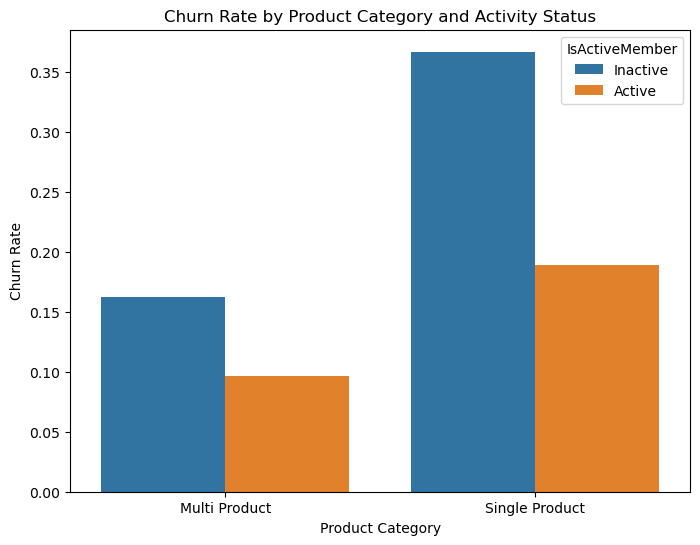

In [38]:
# Create product categories
df['ProductCategory'] = df['NumOfProducts'].apply(
    lambda x: 'Single Product' if x == 1 else 'Multi Product'
)

# Calculate churn rate
product_activity_churn = (
    df.groupby(['ProductCategory', 'IsActiveMember'])['Exited']
    .mean()
    .reset_index()
)

# Rename activity labels
product_activity_churn['IsActiveMember'] = (
    product_activity_churn['IsActiveMember']
    .replace({
        0: 'Inactive',
        1: 'Active'
    })
)

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=product_activity_churn,
    x='ProductCategory',
    y='Exited',
    hue='IsActiveMember'
)

plt.title("Churn Rate by Product Category and Activity Status")
plt.xlabel("Product Category")
plt.ylabel("Churn Rate")

plt.show()

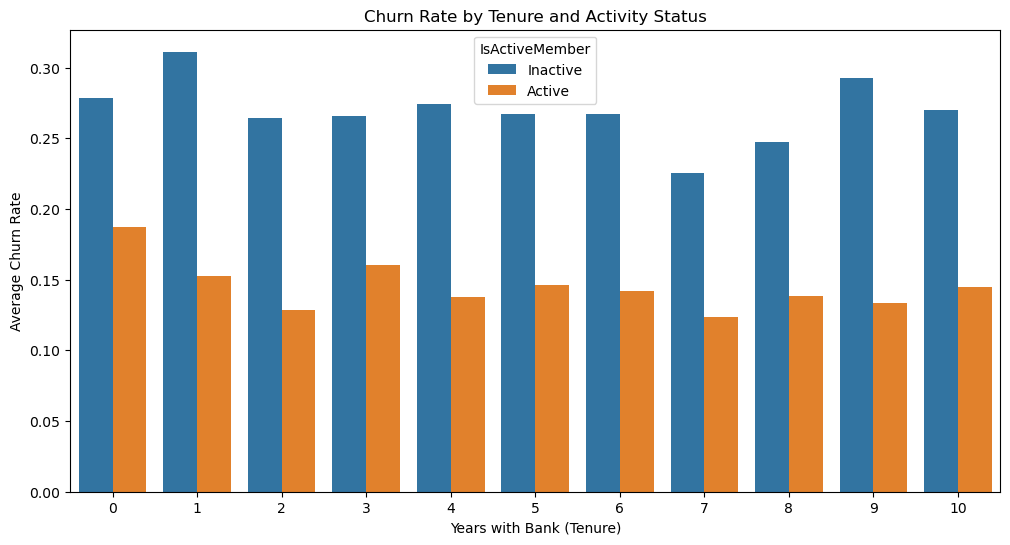

In [39]:
# Calculate churn rate for each combination
tenure_activity_churn = (
    df.groupby(['Tenure', 'IsActiveMember'])['Exited']
    .mean()
    .reset_index()
)

# Rename activity labels
tenure_activity_churn['IsActiveMember'] = (
    tenure_activity_churn['IsActiveMember']
    .replace({
        0: 'Inactive',
        1: 'Active'
    })
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=tenure_activity_churn,
    x='Tenure',
    y='Exited',
    hue='IsActiveMember'
)

plt.title("Churn Rate by Tenure and Activity Status")
plt.xlabel("Years with Bank (Tenure)")
plt.ylabel("Average Churn Rate")

plt.show()

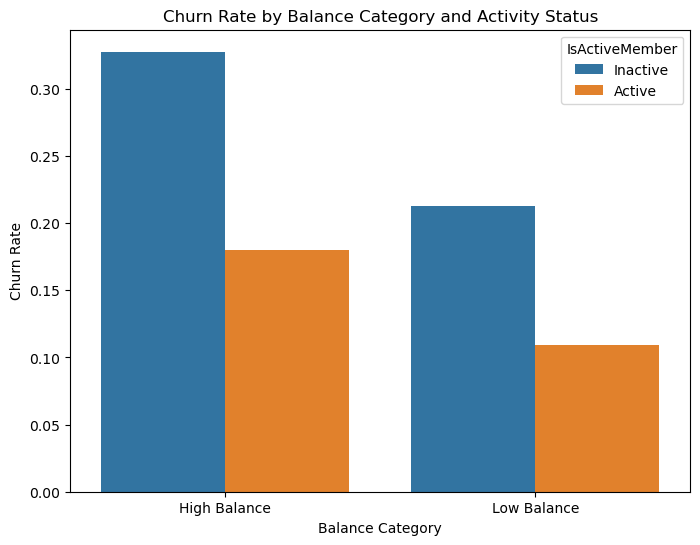

In [40]:
# Create two balance groups
df['BalanceCategory'] = df['Balance'].apply(
    lambda x: 'Low Balance' if x < 100000 else 'High Balance'
)

# Calculate churn rate
balance_activity_churn = (
    df.groupby(['BalanceCategory', 'IsActiveMember'])['Exited']
    .mean()
    .reset_index()
)

# Rename activity labels
balance_activity_churn['IsActiveMember'] = (
    balance_activity_churn['IsActiveMember']
    .replace({
        0: 'Inactive',
        1: 'Active'
    })
)

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=balance_activity_churn,
    x='BalanceCategory',
    y='Exited',
    hue='IsActiveMember'
)

plt.title("Churn Rate by Balance Category and Activity Status")
plt.xlabel("Balance Category")
plt.ylabel("Churn Rate")

plt.show()

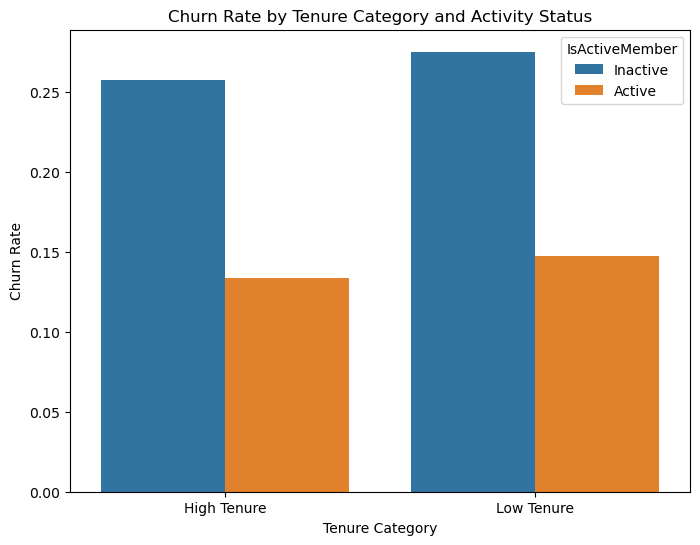

In [41]:
# Create two tenure groups
df['TenureCategory'] = df['Tenure'].apply(
    lambda x: 'Low Tenure' if x < 7 else 'High Tenure'
)

# Calculate churn rate
tenure_activity_churn = (
    df.groupby(['TenureCategory', 'IsActiveMember'])['Exited']
    .mean()
    .reset_index()
)

# Rename activity labels
tenure_activity_churn['IsActiveMember'] = (
    tenure_activity_churn['IsActiveMember']
    .replace({
        0: 'Inactive',
        1: 'Active'
    })
)

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=tenure_activity_churn,
    x='TenureCategory',
    y='Exited',
    hue='IsActiveMember'
)

plt.title("Churn Rate by Tenure Category and Activity Status")
plt.xlabel("Tenure Category")
plt.ylabel("Churn Rate")

plt.show()

# Product Depth Vs Churn Relationship:

In [42]:
def product_depth(row):

    # High relationship depth
    if (
        row['NumOfProducts'] >= 2 and
        row['Tenure'] >= 7
    ):
        return 'High Depth'

    # Medium relationship depth
    elif (
        row['NumOfProducts'] >= 2 or
        row['Tenure'] >= 3
    ):
        return 'Medium Depth'

    # Low relationship depth
    else:
        return 'Low Depth'


df['ProductDepthRange'] = df.apply(product_depth, axis=1)

In [43]:
depth_churn = (
    df.groupby('ProductDepthRange')['Exited']
    .mean()
    .reset_index(name='ChurnRate')
)

depth_churn['ChurnRate'] *= 100

print(depth_churn)

  ProductDepthRange  ChurnRate
0        High Depth  12.442661
1         Low Depth  29.365701
2      Medium Depth  20.704972


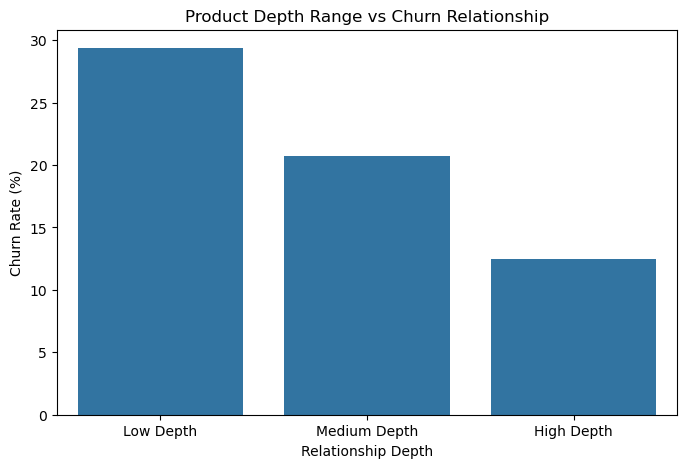

In [44]:
order = ['Low Depth', 'Medium Depth', 'High Depth']
plt.figure(figsize=(8,5))

sns.barplot(
    data=depth_churn,
    x='ProductDepthRange',
    y='ChurnRate',
    order=order
)

plt.title("Product Depth Range vs Churn Relationship")
plt.xlabel("Relationship Depth")
plt.ylabel("Churn Rate (%)")

plt.show()

The analysis demonstrates a strong inverse relationship between relationship depth and churn. Customers with deeper banking relationships, characterized by higher tenure and broader product adoption, exhibit significantly lower churn risk

<Axes: xlabel='IsActiveMember', ylabel='CreditScore'>

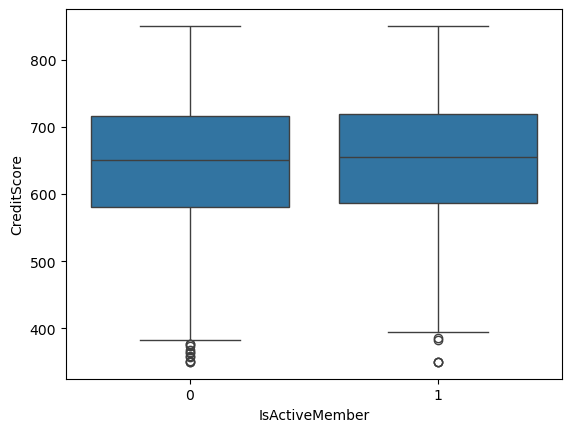

In [45]:
sns.boxplot(
    x='IsActiveMember',
    y='CreditScore',
    data=df
)

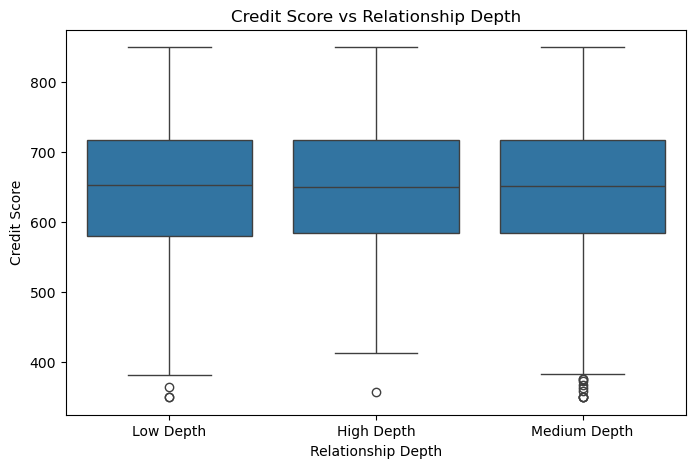

In [46]:
# Credit Score vs Relationship Depth (Product Depth)

plt.figure(figsize=(8,5))

sns.boxplot(
    x='ProductDepthRange',
    y='CreditScore',
    data=df
)

plt.title("Credit Score vs Relationship Depth")
plt.xlabel("Relationship Depth")
plt.ylabel("Credit Score")

plt.show()

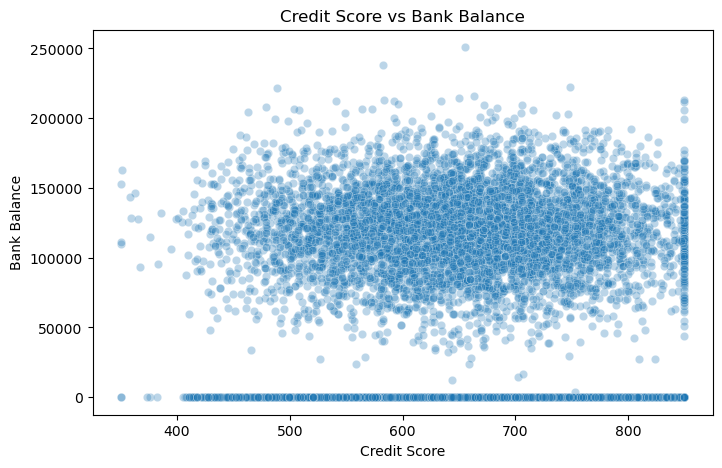

In [47]:
# Credit Score vs Balance

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='CreditScore',
    y='Balance',
    data=df,
    alpha=0.3
)

plt.title("Credit Score vs Bank Balance")
plt.xlabel("Credit Score")
plt.ylabel("Bank Balance")

plt.show()

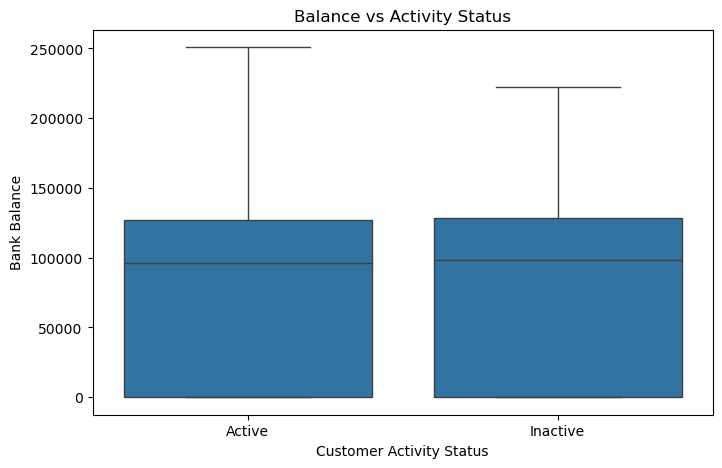

In [48]:
# Rename activity labels
df['ActivityStatus'] = df['IsActiveMember'].replace({
    0: 'Inactive',
    1: 'Active'
})

# Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    x='ActivityStatus',
    y='Balance',
    data=df
)

plt.title("Balance vs Activity Status")
plt.xlabel("Customer Activity Status")
plt.ylabel("Bank Balance")

plt.show()

Balance distributions across activity groups indicate that active customers generally maintain stronger financial engagement. However, the presence of high-balance inactive customers suggests potential silent churn risk among premium customer segments.

In [49]:
#Create salary groups
df['SalaryGroup'] = pd.cut(
    df['EstimatedSalary'],
    bins=[0, 50000, 100000, 200000],
    labels=['Low Salary', 'Medium Salary', 'High Salary']
)
#Create balance groups
df['BalanceGroup'] = pd.cut(
    df['Balance'],
    bins=[0, 50000, 100000, 250000],
    labels=['Low Balance', 'Medium Balance', 'High Balance']
)

C:\Users\conne\AppData\Local\Temp\ipykernel_25016\4240910895.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['SalaryGroup', 'BalanceGroup'])


     SalaryGroup    BalanceGroup  CustomerCount
0     Low Salary     Low Balance             15
1     Low Salary  Medium Balance            360
2     Low Salary    High Balance           1163
3  Medium Salary     Low Balance             23
4  Medium Salary  Medium Balance            383
5  Medium Salary    High Balance           1209
6    High Salary     Low Balance             37
7    High Salary  Medium Balance            766
8    High Salary    High Balance           2426


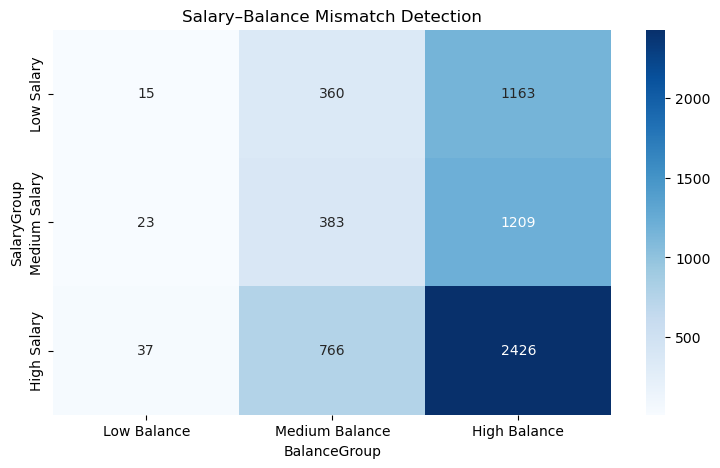

In [50]:
# Cross-analysis
salary_balance_analysis = (
    df.groupby(['SalaryGroup', 'BalanceGroup'])
    .size()
    .reset_index(name='CustomerCount')
)

print(salary_balance_analysis)
plt.figure(figsize=(9,5))

sns.heatmap(
    salary_balance_analysis.pivot(
        index='SalaryGroup',
        columns='BalanceGroup',
        values='CustomerCount'
    ),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Salary–Balance Mismatch Detection")

plt.show()

| Salary   +  Balance                         | Interpretation |
| -------------------------- | ------------------------------- |  
| High Salary + Low Balance  | Weak financial engagement       |                |
| Low Salary + High Balance  | Strong savings/deposit behavior |                |
| High Salary + High Balance | Premium valuable customers      |                |
| Low Salary + Low Balance   | Low-value/basic customers       |                |


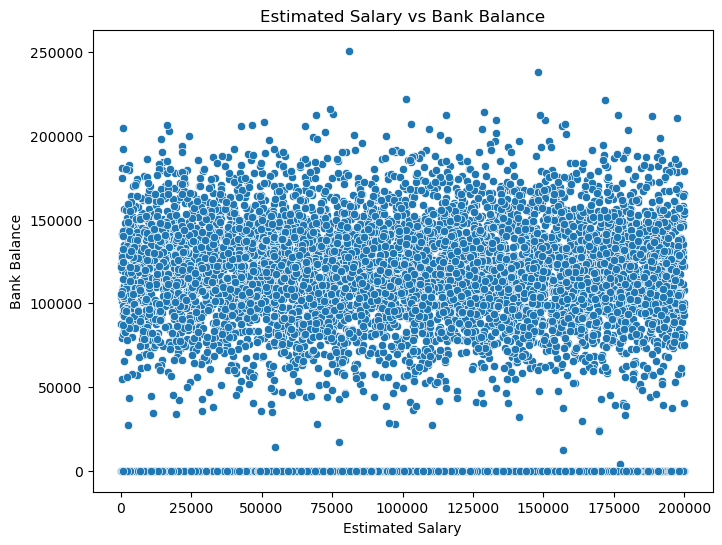

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='EstimatedSalary',
    y='Balance',
    data=df
)

plt.title("Estimated Salary vs Bank Balance")
plt.xlabel("Estimated Salary")
plt.ylabel("Bank Balance")

plt.show()

In [52]:
#Count zero-balance customers
zero_balance_count = (df['Balance'] == 0).sum()

print("Zero Balance Customers:", zero_balance_count)

#Percentage of zero-balance customers
zero_balance_percentage = (
    (df['Balance'] == 0).mean()
) * 100

print("Zero Balance Percentage:", zero_balance_percentage)

#Analyze churn among zero-balance customers
zero_balance_churn = (
    df[df['Balance'] == 0]['Exited']
    .mean()
) * 100

print("Churn Rate for Zero Balance Customers:", zero_balance_churn)

#Compare activity status
df[df['Balance'] == 0]['IsActiveMember'].value_counts()

Zero Balance Customers: 3617
Zero Balance Percentage: 36.17
Churn Rate for Zero Balance Customers: 13.823610727121924


IsActiveMember
1    1873
0    1744
Name: count, dtype: int64

Although zero-balance customers demonstrate weak financial commitment, a substantial proportion remain behaviorally active, suggesting that transactional engagement and financial commitment may not always align.

In [53]:
premium_customers = df[
    (df['Balance'] > 100000) &
    (df['EstimatedSalary'] > 100000)
]

In [54]:
risky_premium = premium_customers[
    (premium_customers['IsActiveMember'] == 0) |
    (premium_customers['Exited'] == 1)
]

In [55]:
risky_premium

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,EstimatedSalary,Exited,AgeGroup2,ProductCategory,BalanceCategory,TenureCategory,ProductDepthRange,ActivityStatus,SalaryGroup,BalanceGroup
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,...,113931.57,1,Younger Customers,Multi Product,High Balance,High Tenure,High Depth,Inactive,High Salary,High Balance
5,2025,15574012,Chu,645,Spain,Male,44,8,113755.78,2,...,149756.71,1,Younger Customers,Multi Product,High Balance,High Tenure,High Depth,Inactive,High Salary,High Balance
7,2025,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,...,119346.88,1,Younger Customers,Multi Product,High Balance,Low Tenure,Medium Depth,Inactive,High Salary,High Balance
41,2025,15738148,Clarke,465,France,Female,51,8,122522.32,1,...,181297.65,1,Older Customers,Single Product,High Balance,High Tenure,Medium Depth,Inactive,High Salary,High Balance
43,2025,15755196,Lavine,834,France,Female,49,2,131394.56,1,...,194365.76,1,Older Customers,Single Product,High Balance,Low Tenure,Low Depth,Inactive,High Salary,High Balance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9970,2025,15587133,Thompson,518,France,Male,42,7,151027.05,2,...,119377.36,0,Younger Customers,Multi Product,High Balance,High Tenure,High Depth,Inactive,High Salary,High Balance
9971,2025,15721377,Chou,833,France,Female,34,3,144751.81,1,...,166472.81,0,Younger Customers,Single Product,High Balance,Low Tenure,Medium Depth,Inactive,High Salary,High Balance
9972,2025,15747927,Ch'in,758,France,Male,26,4,155739.76,1,...,171552.02,0,Younger Customers,Single Product,High Balance,Low Tenure,Medium Depth,Inactive,High Salary,High Balance
9975,2025,15666295,Smith,610,Germany,Male,50,1,113957.01,2,...,196526.55,1,Older Customers,Multi Product,High Balance,Low Tenure,Medium Depth,Inactive,High Salary,High Balance


In [56]:
sticky_customers = df[
    (df['IsActiveMember'] == 1) &
    (df['NumOfProducts'] >= 2) &
    (df['Exited'] == 0) &
    (df['Tenure'] >= 7) 
]

In [57]:
sticky_customers

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,EstimatedSalary,Exited,AgeGroup2,ProductCategory,BalanceCategory,TenureCategory,ProductDepthRange,ActivityStatus,SalaryGroup,BalanceGroup
6,2025,15592531,Bartlett,822,France,Male,50,7,0.00,2,...,10062.80,0,Older Customers,Multi Product,Low Balance,High Tenure,High Depth,Active,Low Salary,NaN
14,2025,15600882,Scott,635,Spain,Female,35,7,0.00,2,...,65951.65,0,Younger Customers,Multi Product,Low Balance,High Tenure,High Depth,Active,Medium Salary,NaN
17,2025,15788218,Henderson,549,Spain,Female,24,9,0.00,2,...,14406.41,0,Younger Customers,Multi Product,Low Balance,High Tenure,High Depth,Active,Low Salary,NaN
20,2025,15577657,McDonald,732,France,Male,41,8,0.00,2,...,170886.17,0,Younger Customers,Multi Product,Low Balance,High Tenure,High Depth,Active,High Salary,NaN
34,2025,15732963,Clements,722,Spain,Female,29,9,0.00,2,...,142033.07,0,Younger Customers,Multi Product,Low Balance,High Tenure,High Depth,Active,High Salary,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9951,2025,15763874,Ho,635,Spain,Male,46,8,0.00,2,...,60739.16,0,Older Customers,Multi Product,Low Balance,High Tenure,High Depth,Active,Medium Salary,NaN
9973,2025,15806455,Miller,611,France,Male,27,7,0.00,2,...,157474.10,0,Younger Customers,Multi Product,Low Balance,High Tenure,High Depth,Active,High Salary,NaN
9977,2025,15579969,Mancini,683,France,Female,32,9,0.00,2,...,24991.92,0,Younger Customers,Multi Product,Low Balance,High Tenure,High Depth,Active,Low Salary,NaN
9984,2025,15696175,Echezonachukwu,602,Germany,Male,35,7,90602.42,2,...,51695.41,0,Younger Customers,Multi Product,Low Balance,High Tenure,High Depth,Active,Medium Salary,Medium Balance


In [58]:
def engagement_tier(row):

    if (
        row['IsActiveMember'] == 1 and
        row['NumOfProducts'] >= 2 and
        row['Tenure'] >= 7
    ):
        return 'High Engagement'

    elif row['IsActiveMember'] == 1:
        return 'Medium Engagement'

    else:
        return 'Low Engagement'


df['EngagementTier'] = df.apply(engagement_tier, axis=1)

In [59]:
tier_churn = (
    df.groupby('EngagementTier')['Exited']
    .mean()
    .reset_index()
)

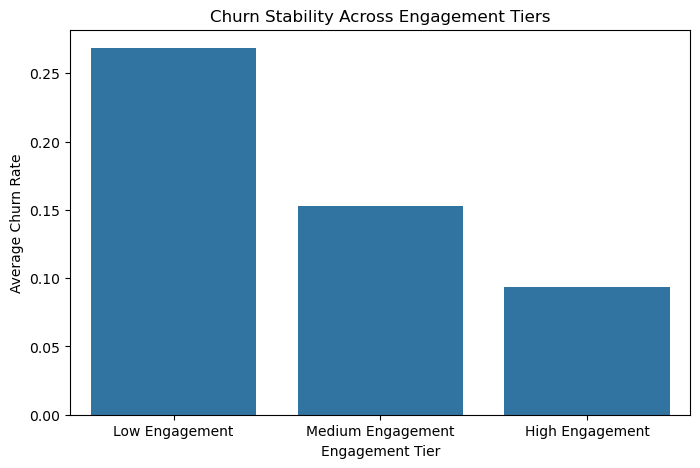

In [60]:
order = ['Low Engagement', 'Medium Engagement', 'High Engagement']

plt.figure(figsize=(8,5))

sns.barplot(
    data=tier_churn,
    x='EngagementTier',
    y='Exited',
    order=order
)

plt.title("Churn Stability Across Engagement Tiers")
plt.xlabel("Engagement Tier")
plt.ylabel("Average Churn Rate")

plt.show()

Customers belonging to the high engagement tier exhibit the greatest stability with the lowest churn rate. Medium and low engagement tiers demonstrate comparatively higher churn tendencies, indicating the need for targeted retention strategies for moderately engaged customers

From above plots we can say Customer retention stability is strongest among active customers with approximately two banking products and longer tenure durations. Inactivity significantly increases churn across all balance tiers, while customers with three or more products demonstrate unusually high churn behavior, indicating potentially unstable or niche customer segments.

In [61]:
engagement_analysis = (
    df.groupby([
        'ActivityStatus',
        'ProductCategory',
        'TenureCategory'
    ])['Exited']
    .mean()
    .reset_index(name='ChurnRate')
)

In [62]:
print(engagement_analysis.sort_values('ChurnRate'))

  ActivityStatus ProductCategory TenureCategory  ChurnRate
0         Active   Multi Product    High Tenure   0.093645
1         Active   Multi Product     Low Tenure   0.098167
4       Inactive   Multi Product    High Tenure   0.157025
5       Inactive   Multi Product     Low Tenure   0.165429
2         Active  Single Product    High Tenure   0.174458
3         Active  Single Product     Low Tenure   0.196916
6       Inactive  Single Product    High Tenure   0.350993
7       Inactive  Single Product     Low Tenure   0.375232


****Single & Multi Product Retention:****

In [63]:
product_impact = (
    df.groupby('ProductCategory')
    .agg(
        TotalCustomers=('Exited', 'count'),
        ChurnedCustomers=('Exited', 'sum')
    )
    .reset_index()
)

# Churn %
product_impact['ChurnRate'] = (
    product_impact['ChurnedCustomers']
    / product_impact['TotalCustomers']
) * 100

# Retention %
product_impact['RetentionRate'] = (
    100 - product_impact['ChurnRate']
)

print(product_impact)

  ProductCategory  TotalCustomers  ChurnedCustomers  ChurnRate  RetentionRate
0   Multi Product            4916               628  12.774614      87.225386
1  Single Product            5084              1409  27.714398      72.285602


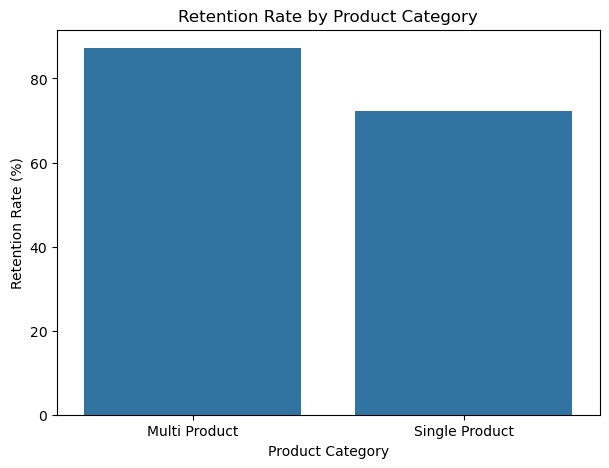

In [64]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=product_impact,
    x='ProductCategory',
    y='RetentionRate'
)

plt.title("Retention Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Retention Rate (%)")

plt.show()

In [65]:
high_value_disengaged = df[
    (df['EstimatedSalary'] >= 100000) &   # High earning potential
    (df['Balance'] < 50000) &             # Low bank commitment
    (df['Tenure'] < 7)  &                 # Weak/early relationship
    (df['IsActiveMember'] == 0)          # Inactive customer
]

# View customers
high_value_disengaged

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,Exited,AgeGroup2,ProductCategory,BalanceCategory,TenureCategory,ProductDepthRange,ActivityStatus,SalaryGroup,BalanceGroup,EngagementTier
13,2025,15691483,Chin,549,France,Female,25,5,0.0,2,...,0,Younger Customers,Multi Product,Low Balance,Low Tenure,Medium Depth,Inactive,High Salary,NaN,Low Engagement
18,2025,15661507,Muldrow,587,Spain,Male,45,6,0.0,1,...,0,Younger Customers,Single Product,Low Balance,Low Tenure,Medium Depth,Inactive,High Salary,NaN,Low Engagement
22,2025,15699309,Gerasimov,510,Spain,Female,38,4,0.0,1,...,1,Younger Customers,Single Product,Low Balance,Low Tenure,Medium Depth,Inactive,High Salary,NaN,Low Engagement
30,2025,15589475,Azikiwe,591,Spain,Female,39,3,0.0,3,...,1,Younger Customers,Multi Product,Low Balance,Low Tenure,Medium Depth,Inactive,High Salary,NaN,Low Engagement
52,2025,15683553,O'Brien,788,France,Female,33,5,0.0,2,...,0,Younger Customers,Multi Product,Low Balance,Low Tenure,Medium Depth,Inactive,High Salary,NaN,Low Engagement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9919,2025,15798084,Murray,688,France,Male,26,0,0.0,2,...,0,Younger Customers,Multi Product,Low Balance,Low Tenure,Medium Depth,Inactive,High Salary,NaN,Low Engagement
9957,2025,15672237,Oluchi,633,France,Male,25,1,0.0,1,...,0,Younger Customers,Single Product,Low Balance,Low Tenure,Low Depth,Inactive,High Salary,NaN,Low Engagement
9983,2025,15656710,Cocci,613,France,Male,40,4,0.0,1,...,0,Younger Customers,Single Product,Low Balance,Low Tenure,Medium Depth,Inactive,High Salary,NaN,Low Engagement
9992,2025,15657105,Chukwualuka,726,Spain,Male,36,2,0.0,1,...,0,Younger Customers,Single Product,Low Balance,Low Tenure,Low Depth,Inactive,High Salary,NaN,Low Engagement


## Engagement-driven retention strategies

Based on above analysis, the strongest engagement indicators are:

1.Activity status

2.Product adoption

3.Tenure

4.Financial commitment (balance)

in following manner:

- Active customers churn less.
- Multi-product customers are more stable.
- Longer-tenure customers retain better.
- High salary + low balance + inactivity may indicate disengaged high-potential customers.

These insights directly support engagement-based retention planning.

**Business interpretation -**

The bank should:

strengthen customer engagement,      
increase activity,           
deepen product relationships,            
and proactively target disengaged customers.

**Example engagement-driven retention strategies:**               
   
| Customer Type | Strategy |
|---|---|
| Inactive customers | Reactivation campaigns |
| Single-product customers | Cross-selling additional products |
| Low-tenure customers | Early onboarding engagement |
| High-value disengaged customers | Personalized premium outreach |
| Low-balance high-salary customers | Wealth management offers |              

    

The above graphs showed:
    
- activity status strongly impacts churn
    
- multi-product customers retain better
    
- engagement tiers correlate with retention stability.

So we can conclude:

**Retention performance improves significantly with higher customer engagement, indicating the importance of engagement-driven retention strategies in reducing churn risk.**

## Potential bundling targets:

In [66]:
bundle_targets = df[
    (df['IsActiveMember'] == 1) &
    (df['NumOfProducts'] == 1) &
    (df['EstimatedSalary'] >= 100000)
]

bundle_targets

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,Exited,AgeGroup2,ProductCategory,BalanceCategory,TenureCategory,ProductDepthRange,ActivityStatus,SalaryGroup,BalanceGroup,EngagementTier
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,1,Younger Customers,Single Product,Low Balance,Low Tenure,Low Depth,Active,High Salary,NaN,Medium Engagement
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,0,Younger Customers,Single Product,Low Balance,Low Tenure,Low Depth,Active,High Salary,Medium Balance,Medium Engagement
24,2025,15625047,Yen,846,France,Female,38,5,0.00,1,...,0,Younger Customers,Single Product,Low Balance,Low Tenure,Medium Depth,Active,High Salary,NaN,Medium Engagement
26,2025,15736816,Young,756,Germany,Male,36,2,136815.64,1,...,0,Younger Customers,Single Product,High Balance,Low Tenure,Low Depth,Active,High Salary,High Balance,Medium Engagement
28,2025,15728693,McWilliams,574,Germany,Female,43,3,141349.43,1,...,0,Younger Customers,Single Product,High Balance,Low Tenure,Medium Depth,Active,High Salary,High Balance,Medium Engagement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9934,2025,15774586,West,692,Germany,Female,43,10,118588.83,1,...,1,Younger Customers,Single Product,High Balance,High Tenure,Medium Depth,Active,High Salary,High Balance,Medium Engagement
9960,2025,15681026,Lucciano,795,Germany,Female,33,9,104552.72,1,...,1,Younger Customers,Single Product,High Balance,High Tenure,Medium Depth,Active,High Salary,High Balance,Medium Engagement
9967,2025,15603794,Pugliesi,623,France,Male,48,5,118469.38,1,...,0,Older Customers,Single Product,High Balance,Low Tenure,Medium Depth,Active,High Salary,High Balance,Medium Engagement
9969,2025,15806360,Hou,609,France,Male,41,6,0.00,1,...,0,Younger Customers,Single Product,Low Balance,Low Tenure,Medium Depth,Active,High Salary,NaN,Medium Engagement


**Business interpretation**

These customers
are active,
financially capable,
but underutilizing bank services.

So they are strong candidates for:

- credit cards,
- investment products,
- insurance,
- premium banking bundles.
    
**Example strategic conclusions**
    
| Customer Type | Product Bundling Strategy |
|---|---|
| Active single-product customers | Cross-sell additional banking products |
| High-salary customers | Offer premium banking bundles |
| Long-tenure customers | Loyalty-based bundled services |
| High-balance customers | Wealth management and investment bundles |
| Multi-product active customers | Retention-focused premium packages |

So, we can say

**Customer engagement and retention patterns indicate that multi-product relationships contribute significantly to customer stability, supporting the need for targeted product bundling and cross-selling strategies.**

## premium customers with potential silent churn

In [67]:
silent_churn_premium = df[
    (df['EstimatedSalary'] >= 100000) &   # High-value customers
    (df['Balance'] >= 100000) &           # Strong financial value
    (df['IsActiveMember'] == 0) &         # Disengaged/inactive
    (df['Tenure'] >= 5) &                  # Long relationship history
    (df['CreditScore'] >= 700)             # High credit score
    ]

# View customers
silent_churn_premium

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,Exited,AgeGroup2,ProductCategory,BalanceCategory,TenureCategory,ProductDepthRange,ActivityStatus,SalaryGroup,BalanceGroup,EngagementTier
91,2025,15731511,Ritchie,808,France,Male,45,7,118626.55,2,...,0,Younger Customers,Multi Product,High Balance,High Tenure,High Depth,Inactive,High Salary,High Balance,Low Engagement
129,2025,15591607,Fernie,770,France,Male,24,9,101827.07,1,...,0,Younger Customers,Single Product,High Balance,High Tenure,Medium Depth,Inactive,High Salary,High Balance,Low Engagement
140,2025,15698932,Groves,756,Germany,Male,44,10,137452.09,1,...,0,Younger Customers,Single Product,High Balance,High Tenure,Medium Depth,Inactive,High Salary,High Balance,Low Engagement
166,2025,15724623,Taubman,704,Germany,Female,24,7,113034.22,1,...,1,Younger Customers,Single Product,High Balance,High Tenure,Medium Depth,Inactive,High Salary,High Balance,Low Engagement
241,2025,15651001,Tsao,725,Germany,Female,39,5,116803.80,1,...,0,Younger Customers,Single Product,High Balance,Low Tenure,Medium Depth,Inactive,High Salary,High Balance,Low Engagement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9708,2025,15604515,Yefremov,737,Germany,Female,22,10,111543.26,2,...,0,Younger Customers,Multi Product,High Balance,High Tenure,High Depth,Inactive,High Salary,High Balance,Low Engagement
9812,2025,15711572,O'Kane,705,Germany,Female,31,9,110941.93,2,...,0,Younger Customers,Multi Product,High Balance,High Tenure,High Depth,Inactive,High Salary,High Balance,Low Engagement
9893,2025,15598331,Morgan,764,France,Female,40,9,100480.53,1,...,0,Younger Customers,Single Product,High Balance,High Tenure,Medium Depth,Inactive,High Salary,High Balance,Low Engagement
9942,2025,15683007,Torode,739,Germany,Female,25,5,113113.12,1,...,0,Younger Customers,Single Product,High Balance,Low Tenure,Medium Depth,Inactive,High Salary,High Balance,Low Engagement


This identifies:

premium/high-value customers,
who have strong banking relationships,
but are becoming behaviorally disengaged.

| Premium Customer Segment | Silent-Churn Reduction Strategy |
|---|---|
| Inactive multi-product premium customers | Personalized relationship recovery campaigns |
| High-salary low-balance customers | Wealth management and financial engagement offers |
| Long-tenure inactive customers | Loyalty retention and reactivation programs |
| Premium single-product customers | Premium cross-selling and bundled product offers |
| High-balance inactive customers | Dedicated premium relationship management |
| Active high-value customers with low product adoption | Product bundling and upselling strategies |

In [68]:
card_churn = (
    df.groupby('HasCrCard')['Exited']
    .mean()
    .reset_index(name='ChurnRate')
)

card_churn['ChurnRate'] *= 100

print(card_churn)

   HasCrCard  ChurnRate
0          0  20.814941
1          1  20.184266


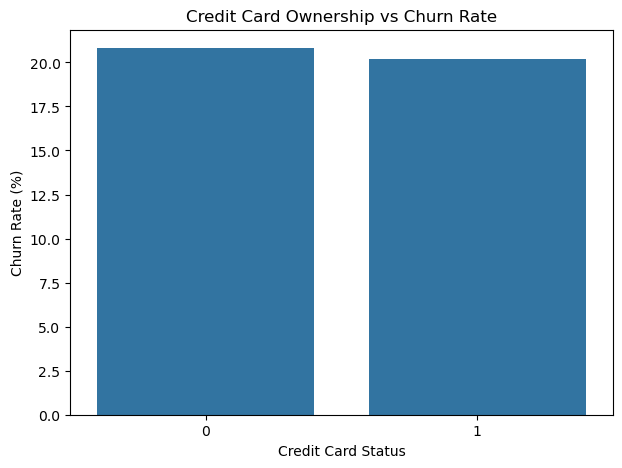

In [69]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=card_churn,
    x='HasCrCard',
    y='ChurnRate'
)

plt.title("Credit Card Ownership vs Churn Rate")
plt.xlabel("Credit Card Status")
plt.ylabel("Churn Rate (%)")

plt.show()

Credit card ownership demonstrated limited influence on churn behavior compared to engagement and relationship-depth variables.

In [70]:
credit_churn = (
    df.groupby('CreditScore')['Exited']
    .mean()
    .reset_index(name='ChurnRate')
)

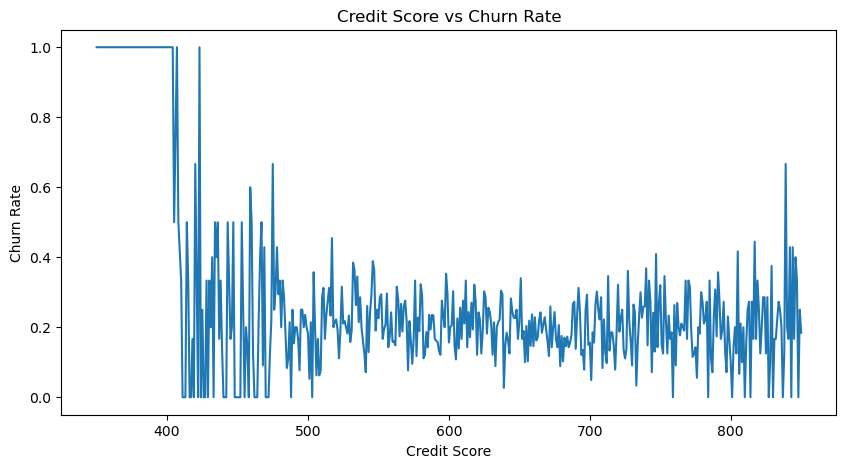

In [71]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=credit_churn,
    x='CreditScore',
    y='ChurnRate'
)

plt.title("Credit Score vs Churn Rate")
plt.xlabel("Credit Score")
plt.ylabel("Churn Rate")

plt.show()

In [72]:
# Create 2 credit tiers

df['CreditTier2'] = pd.cut(
    df['CreditScore'],
    bins=[0, 650, 1000],
    labels=['Low Credit', 'High Credit']
)

In [73]:
credit_tier2_churn = (
    df.groupby('CreditTier2')['Exited']
    .mean()
    .reset_index(name='ChurnRate')
)

credit_tier2_churn['ChurnRate'] *= 100

print(credit_tier2_churn)

   CreditTier2  ChurnRate
0   Low Credit  21.409763
1  High Credit  19.356113


C:\Users\conne\AppData\Local\Temp\ipykernel_25016\1257609660.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CreditTier2')['Exited']


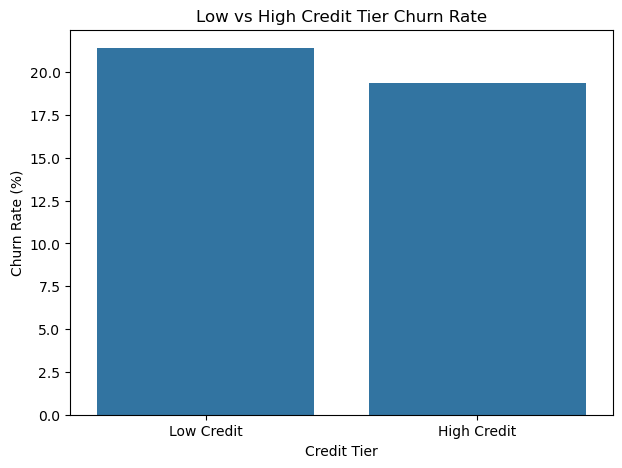

In [74]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=credit_tier2_churn,
    x='CreditTier2',
    y='ChurnRate'
)

plt.title("Low vs High Credit Tier Churn Rate")
plt.xlabel("Credit Tier")
plt.ylabel("Churn Rate (%)")

plt.show()

Customers with lower credit quality exhibit somewhat higher churn tendencies, although the overall impact of credit tier on churn appears moderate compared to engagement and relationship-depth variables.



In [75]:
df

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,AgeGroup2,ProductCategory,BalanceCategory,TenureCategory,ProductDepthRange,ActivityStatus,SalaryGroup,BalanceGroup,EngagementTier,CreditTier2
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,Younger Customers,Single Product,Low Balance,Low Tenure,Low Depth,Active,High Salary,NaN,Medium Engagement,Low Credit
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,Younger Customers,Single Product,Low Balance,Low Tenure,Low Depth,Active,High Salary,Medium Balance,Medium Engagement,Low Credit
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,...,Younger Customers,Multi Product,High Balance,High Tenure,High Depth,Inactive,High Salary,High Balance,Low Engagement,Low Credit
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,...,Younger Customers,Multi Product,Low Balance,Low Tenure,Medium Depth,Inactive,Medium Salary,NaN,Low Engagement,High Credit
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,Younger Customers,Single Product,High Balance,Low Tenure,Low Depth,Active,Medium Salary,High Balance,Medium Engagement,High Credit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,...,Younger Customers,Multi Product,Low Balance,Low Tenure,Medium Depth,Inactive,Medium Salary,NaN,Low Engagement,High Credit
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,...,Younger Customers,Single Product,Low Balance,High Tenure,Medium Depth,Active,High Salary,Medium Balance,Medium Engagement,Low Credit
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,...,Younger Customers,Single Product,Low Balance,High Tenure,Medium Depth,Active,Low Salary,NaN,Medium Engagement,High Credit
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,...,Younger Customers,Multi Product,Low Balance,Low Tenure,Medium Depth,Inactive,Medium Salary,Medium Balance,Low Engagement,High Credit


# Feature Encoding

In [76]:
# Convert categorical variables into numerical values

# Product Category
df['ProductCategory_Num'] = df['ProductCategory'].map({
    'Single Product': 0,
    'Multi Product': 1
})

# Credit Tier 

df['CreditTier2_Num'] = df['CreditTier2'].map({
    'Low Credit': 0,
    'High Credit': 1
})

#  Age

df['AgeGroup2_Num'] = df['AgeGroup2'].map({
    'Younger Customers': 0,
    'Older Customers': 1
})

# Balance Category
df['BalanceCategory_Num'] = df['BalanceCategory'].map({
    'Low Balance': 0,
    'Medium Balance': 1,
    'High Balance': 2
})

# Tenure Category
df['TenureCategory_Num'] = df['TenureCategory'].map({
    'Low Tenure': 0,
    'Medium Tenure': 1,
    'High Tenure': 2
})

# Product Depth Range
df['ProductDepth_Num'] = df['ProductDepthRange'].map({
    'Low Depth': 0,
    'Medium Depth': 1,
    'High Depth': 2
})

# Salary Group
df['SalaryGroup_Num'] = df['SalaryGroup'].map({
    'Low Salary': 0,
    'Medium Salary': 1,
    'High Salary': 2,
    'Very High': 3
})

# Balance Group
df['BalanceGroup_Num'] = df['BalanceGroup'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'Very High': 3
})

# Replace NaN in BalanceGroup_Num with Low Balance (0)
df['BalanceGroup_Num'] = df['BalanceGroup_Num'].fillna(0)

# Engagement Tier
df['EngagementTier_Num'] = df['EngagementTier'].map({
    'Low Engagement': 0,
    'Medium Engagement': 1,
    'High Engagement': 2
})


In [77]:
# One-Hot Encoding for Geography and Gender

df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True
)

In [78]:
df

,Year,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,...,AgeGroup2_Num,BalanceCategory_Num,TenureCategory_Num,ProductDepth_Num,SalaryGroup_Num,BalanceGroup_Num,EngagementTier_Num,Geography_Germany,Geography_Spain,Gender_Male
0,2025,15634602,Hargrave,619,42,2,0.00,1,1,1,...,0,0,0,0,2,0.0,1,False,False,False
1,2025,15647311,Hill,608,41,1,83807.86,1,0,1,...,0,0,0,0,2,0.0,1,False,True,False
2,2025,15619304,Onio,502,42,8,159660.80,3,1,0,...,0,2,2,2,2,0.0,0,False,False,False
3,2025,15701354,Boni,699,39,1,0.00,2,0,0,...,0,0,0,1,1,0.0,0,False,False,False
4,2025,15737888,Mitchell,850,43,2,125510.82,1,1,1,...,0,2,0,0,1,0.0,1,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,15606229,Obijiaku,771,39,5,0.00,2,1,0,...,0,0,0,1,1,0.0,0,False,False,True
9996,2025,15569892,Johnstone,516,35,10,57369.61,1,1,1,...,0,0,2,1,2,0.0,1,False,False,True
9997,2025,15584532,Liu,709,36,7,0.00,1,0,1,...,0,0,2,1,0,0.0,1,False,False,False
9998,2025,15682355,Sabbatini,772,42,3,75075.31,2,1,0,...,0,0,0,1,1,0.0,0,True,False,True


# Plotting HeatMap

In [79]:
correlation_data = df[['HasCrCard','IsActiveMember','ProductCategory_Num', 'CreditTier2_Num',
       'AgeGroup2_Num', 'BalanceCategory_Num', 'TenureCategory_Num',
       'ProductDepth_Num', 'SalaryGroup_Num',
       'EngagementTier_Num', 'Geography_Germany', 'Geography_Spain',
       'Gender_Male','Exited']]

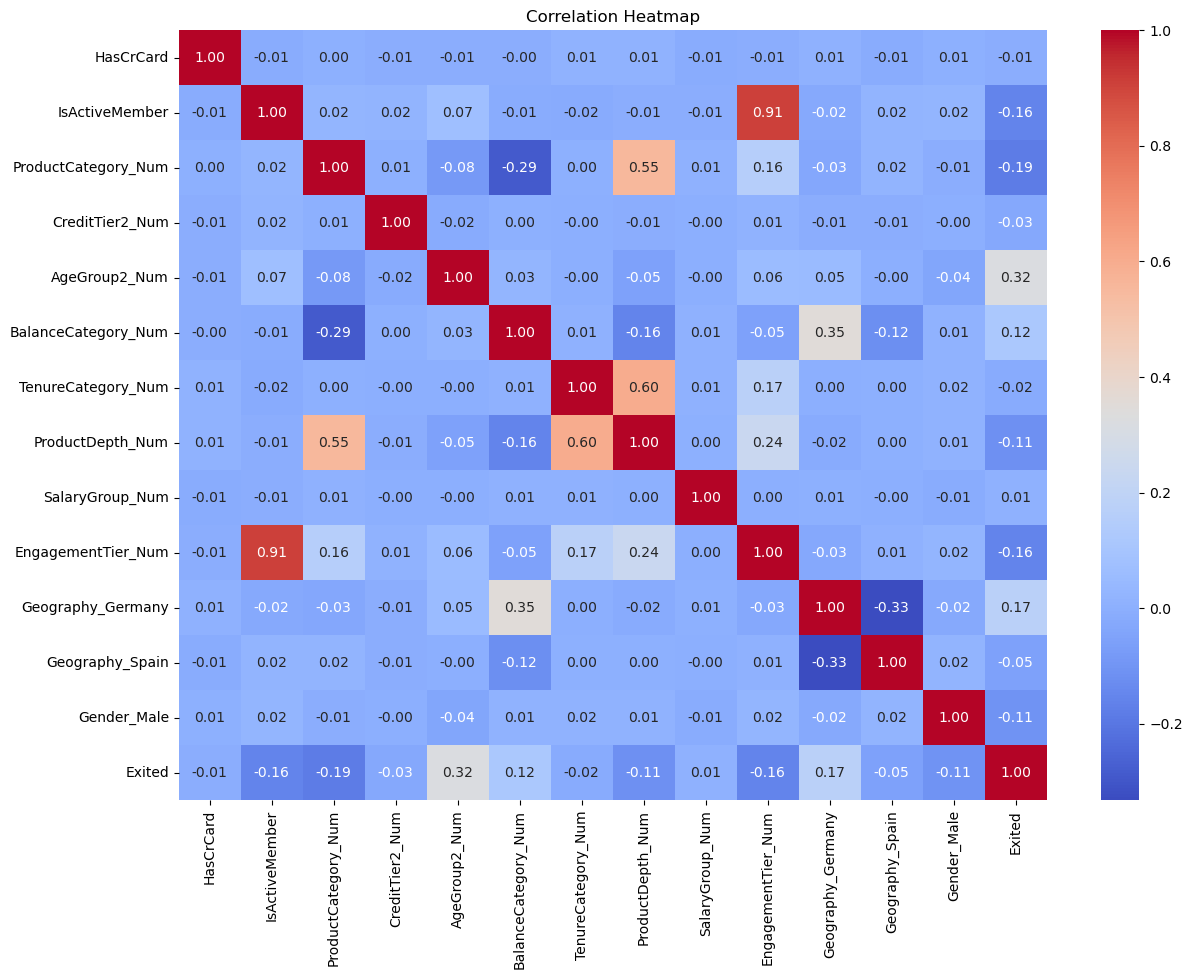

In [80]:
# Correlation matrix
corr_matrix = correlation_data.corr()

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

**Strong churn drivers:** 
- Age
- Activity
- Product relationship depth
- Engagement

**Moderate drivers:**
- Balance behavior
- Geography

**Weak drivers:**
- Credit card ownership
- Credit score

#  Split data into features & target variable

In [81]:
X = df[['HasCrCard','IsActiveMember','ProductCategory_Num', 'CreditTier2_Num',
       'AgeGroup2_Num', 'BalanceCategory_Num', 'TenureCategory_Num',
       'ProductDepth_Num', 'SalaryGroup_Num', 'Geography_Germany', 'Geography_Spain']]

y = df['Exited']

In [82]:
X = X.astype(float)

In [83]:
X.isnull().sum()

HasCrCard              0
IsActiveMember         0
ProductCategory_Num    0
CreditTier2_Num        0
AgeGroup2_Num          0
BalanceCategory_Num    0
TenureCategory_Num     0
ProductDepth_Num       0
SalaryGroup_Num        0
Geography_Germany      0
Geography_Spain        0
dtype: int64

# Train Test Split

In [84]:
# Split dataset into train test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify =y)

# test_size=0.2: 20% of the data is used for testing, and 80% for training.
# random_state=42: Ensures reproducibility by fixing the random seed.
# Stratify ensures the same proportion of responders and non-responders in train and test sets

# Predictive Modeling – ML Algorithms
---

### Developing
- Logistic Regression
- Decision Tree  
- Random Forest 
- XGBoost
- LightGBM
- SVM
- KNN

---

## Logistic Regression

In [85]:
# =====================================
# SCALING
# FIT ONLY ON TRAINING DATA
# =====================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) 

#StandardScaler is applied to normalize features,which is essential for distance-based models like Logistic Regression

X_test_scaled = scaler.transform(X_test)


In [86]:
smote = SMOTE(random_state=42)

# =====================================
# APPLY SMOTE ONLY ON TRAINING DATA 
# =====================================
                      
smote = SMOTE(random_state=42)                      # For handling class imbalance

X_train_scaled_smote, y_train_smote = smote.fit_resample(

    X_train_scaled,
    y_train

)

In [87]:
y_train.value_counts()

Exited
0    6370
1    1630
Name: count, dtype: int64

In [88]:
y_train_smote.value_counts()

Exited
1    6370
0    6370
Name: count, dtype: int64

**Cross Validation**

In [89]:

# Stratified CV
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,                         # Stratified cv for imbalanced data
    random_state=42
)

# Logistic Regression model
log_reg = LogisticRegression(
    max_iter=2000                        # Defines maximum numbers of iteration
)

# Cross-validation recall scores
cv_scores = cross_val_score(
    log_reg,
    X_train_scaled_smote,
    y_train_smote,
    cv=cv_strategy,
    scoring='recall'
)

# Results
print("Recall Scores:", cv_scores)

print("Average Recall:", cv_scores.mean())

Recall Scores: [0.68053375 0.72605965 0.69858713 0.67660911 0.68759812]
Average Recall: 0.6938775510204082


In [90]:
# Fit Logistic Regression Model
log_reg.fit(X_train_scaled_smote, y_train_smote)

# Predictions
y_pred_log = log_reg.predict(X_test)

# Probability predictions for ROC-AUC
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

C:\Users\conne\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\conne\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [93]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_log)

precision = precision_score(y_test, y_pred_log)

recall = recall_score(y_test, y_pred_log)

f1 = f1_score(y_test, y_pred_log)

roc_auc = roc_auc_score(y_test, y_prob_log)


# Print results
print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("ROC-AUC Score :", roc_auc)

print(classification_report(y_test, y_pred_log))

Accuracy : 0.7805
Precision : 0.46208530805687204
Recall : 0.47911547911547914
F1 Score : 0.4704463208685163
ROC-AUC Score : 0.7530874480027023
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1593
           1       0.46      0.48      0.47       407

    accuracy                           0.78      2000
   macro avg       0.66      0.67      0.67      2000
weighted avg       0.78      0.78      0.78      2000



In [94]:
# Create confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
cm_log

array([[1366,  227],
       [ 212,  195]])

---

## Decision Tree Classifier

In [95]:
# =====================================
# APPLY SMOTE ONLY ON TRAINING DATA
# =====================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train,
    y_train

)

In [97]:
# Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter grid
param_grid_dt = {
    "max_depth": [10, 20],                          # Controls tree depth to prevent overfitting.
    "min_samples_split": [5, 10],                   # Specifies the minimum number of samples required to split a node
    "min_samples_leaf": [5, 10],                    # Ensures each leaf has at least one sample, allowing fine-grained splits.
    "max_features": ["sqrt"],                       # Limits the number of features considered at each split to reduce correlation among trees.
    "criterion": ["gini", "entropy"]                # impurity measures
}

# GridSearchCV is used to find the optimal hyperparameters
grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=cv_strategy,
    scoring='recall',   
    n_jobs=-1,
    verbose=2
)

# Train model
grid_search_dt.fit(X_train_smote, y_train_smote)

# Best model
best_dt = grid_search_dt.best_estimator_

# Generate predictions using the trained Decision
y_pred_dt = best_dt.predict(X_test)

# Probabilities for ROC-AUC
y_prob_dt = best_dt.predict_proba(X_test)[:,1]

# Evaluation
print("Best Parameters:")
print(grid_search_dt.best_params_)

print("\nAccuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\nConfusion Matrix:")
print(cm_dt)


print("Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters:
{'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5}

Accuracy: 0.7635
Precision: 0.43843283582089554
Recall: 0.5773955773955773
F1 Score: 0.4984093319194062
ROC-AUC: 0.7279351770877194

Confusion Matrix:
[[1292  301]
 [ 172  235]]
Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1593
           1       0.44      0.58      0.50       407

    accuracy                           0.76      2000
   macro avg       0.66      0.69      0.67      2000
weighted avg       0.79      0.76      0.77      2000



---

## Random Forest Classifier

In [98]:
# Base model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],       # Sets the number of trees in the forest to improve model stability.
    'max_depth': [5, 10, 15, 20],           # Controls tree depth to prevent overfitting.
    'min_samples_split': [2, 5, 10],        # Specifies the minimum number of samples required to split a node.
    'min_samples_leaf': [1, 2, 4],          # Ensures each leaf has at least one sample, allowing fine-grained splits.
    'max_features': ['sqrt', 'log2']        # Limits the number of features considered at each split to reduce correlation among trees.
}

# Grid Search with Cross Validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

# Train model
grid_search.fit(X_train_smote, y_train_smote)

# Best model
best_rf = grid_search.best_estimator_

# Train the final Random Forest model using the best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}


In [99]:
# Predictions
y_pred_rf =best_rf.predict(X_test)

# Probability predictions
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

In [100]:
# Evaluate model performance using confusion matrix and classification report

accuracy = accuracy_score(y_test, y_pred_rf)

precision = precision_score(y_test, y_pred_rf)

recall = recall_score(y_test, y_pred_rf)

f1 = f1_score(y_test, y_pred_rf)

roc_auc = roc_auc_score(y_test, y_prob_rf)

# Print results
print("Random Forest Results\n")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("ROC-AUC Score :", roc_auc)

print(classification_report(y_test, y_pred_rf))

Random Forest Results

Accuracy : 0.7795
Precision : 0.46336206896551724
Recall : 0.5282555282555282
F1 Score : 0.4936854190585534
ROC-AUC Score : 0.7365300585639568
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1593
           1       0.46      0.53      0.49       407

    accuracy                           0.78      2000
   macro avg       0.67      0.69      0.68      2000
weighted avg       0.79      0.78      0.78      2000



In [101]:
# Create confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

array([[1344,  249],
       [ 192,  215]])

---

## Extreme Gradient Boosting Classifier

In [103]:
# Base XGBoost model

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Hyperparameter grid
param_grid_xgb ={
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],                  # Limits tree depth to prevent overfitting.
    'learning_rate': [0.01, 0.05, 0.1],      # Uses a fraction of data per tree to improve generalization
    'subsample': [0.8, 1.0],                 # Determines how much each tree contributes to the final model.
    'colsample_bytree': [0.8, 1.0],            # Uses a fraction of data per tree to improve generalization.
    'gamma': [0, 0.1, 0.3]                   # Samples a subset of features for each tree to reduce correlation.
   
}

# Grid Search with Cross Validation
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring='recall',   
    n_jobs=-1,                          # Utilizes all available CPU cores for faster computation.
    verbose=2                           # Displays progress of the hyperparameter search.
)

# Train model
grid_search_xgb.fit(
    X_train_smote,
    y_train_smote
)

# Best model
best_xgb = grid_search_xgb.best_estimator_

print("Best Parameters:")
print(grid_search_xgb.best_params_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters:
{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


In [104]:
# Predictions

y_pred_xgb = best_xgb.predict(X_test)

# Probability predictions
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

In [105]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_xgb)

precision = precision_score(y_test, y_pred_xgb)

recall = recall_score(y_test, y_pred_xgb)

f1 = f1_score(y_test, y_pred_xgb)

roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Tuned Results\n")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("ROC-AUC Score :", roc_auc)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Tuned Results

Accuracy : 0.7695
Precision : 0.4369158878504673
Recall : 0.4594594594594595
F1 Score : 0.4479041916167665
ROC-AUC Score : 0.7265293028004893
Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1593
           1       0.44      0.46      0.45       407

    accuracy                           0.77      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.77      0.77      0.77      2000



In [106]:
# Create confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_xgb

array([[1352,  241],
       [ 220,  187]])

---

## LightGBM Classifier

In [107]:
# Base LightGBM model

lgbm_model = LGBMClassifier(
    random_state=42
)

# Hyperparameter grid
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'num_leaves': [20, 31, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid Search with Cross Validation
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

# Train model
grid_search_lgbm.fit(
    X_train_smote,
    y_train_smote
)

# Best model
best_lgbm = grid_search_lgbm.best_estimator_

print("Best Parameters:")
print(grid_search_lgbm.best_params_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1905
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'num_leaves': 50, 'subsample': 0.8}


In [108]:
# Predictions

y_pred_lgbm = best_lgbm.predict(X_test)

# Probability predictions
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

In [109]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_lgbm)

precision = precision_score(y_test, y_pred_lgbm)

recall = recall_score(y_test, y_pred_lgbm)

f1 = f1_score(y_test, y_pred_lgbm)

roc_auc = roc_auc_score(y_test, y_prob_lgbm)

print("LightGBM Results\n")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("ROC-AUC Score :", roc_auc)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgbm))

LightGBM Results

Accuracy : 0.766
Precision : 0.4314606741573034
Recall : 0.47174447174447176
F1 Score : 0.4507042253521127
ROC-AUC Score : 0.7294166277217125

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      1593
           1       0.43      0.47      0.45       407

    accuracy                           0.77      2000
   macro avg       0.65      0.66      0.65      2000
weighted avg       0.77      0.77      0.77      2000



In [110]:
# Create confusion matrix
cm_lgbm= confusion_matrix(y_test, y_pred_lgbm)
cm_lgbm

array([[1340,  253],
       [ 215,  192]])

---

## Suppprt Vector Machine Classifier

In [111]:
# Base SVM model

svm_model = SVC(
    probability=True,
    random_state=42
)

# Hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Grid Search with Cross Validation
grid_search_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Train model
grid_search_svm.fit(
    X_train_scaled_smote,
    y_train_smote
)

# Best model
best_svm = grid_search_svm.best_estimator_

print("Best Parameters:")
print(grid_search_svm.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [112]:
# Predictions

y_pred_svm = best_svm.predict(X_test_scaled)

# Probability predictions
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

In [113]:
# Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred_svm)

precision = precision_score(y_test, y_pred_svm)

recall = recall_score(y_test, y_pred_svm)

f1 = f1_score(y_test, y_pred_svm)

roc_auc = roc_auc_score(y_test, y_prob_svm)

print("SVM Results\n")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("ROC-AUC Score :", roc_auc)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Results

Accuracy : 0.7475
Precision : 0.4128113879003559
Recall : 0.5700245700245701
F1 Score : 0.478844169246646
ROC-AUC Score : 0.723928088334868

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83      1593
           1       0.41      0.57      0.48       407

    accuracy                           0.75      2000
   macro avg       0.65      0.68      0.66      2000
weighted avg       0.78      0.75      0.76      2000



In [114]:
# Create confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_svm

array([[1263,  330],
       [ 175,  232]])

---
## K Nearest Neighbors Classifier

In [115]:
# Base KNN model

knn_model = KNeighborsClassifier()

# Hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Grid Search with Cross Validation
grid_search_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Train model
grid_search_knn.fit(
    X_train_scaled_smote,
    y_train_smote
)

# Best model
best_knn = grid_search_knn.best_estimator_

print("Best Parameters:")
print(grid_search_knn.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}


In [116]:
# Predictions

y_pred_knn = best_knn.predict(X_test_scaled)

# Probability predictions
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

In [117]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_knn)

precision = precision_score(y_test, y_pred_knn)

recall = recall_score(y_test, y_pred_knn)

f1 = f1_score(y_test, y_pred_knn)

roc_auc = roc_auc_score(y_test, y_prob_knn)

print("KNN Results\n")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("ROC-AUC Score :", roc_auc)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

KNN Results

Accuracy : 0.8115
Precision : 0.56
Recall : 0.343980343980344
F1 Score : 0.426179604261796
ROC-AUC Score : 0.6914834711444882

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83      1593
           1       0.41      0.57      0.48       407

    accuracy                           0.75      2000
   macro avg       0.65      0.68      0.66      2000
weighted avg       0.78      0.75      0.76      2000



In [118]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

In [119]:
cm

array([[1483,  110],
       [ 267,  140]])

# Comparison of Model Performance

In [120]:
# Store all models
models = {
    'Logistic Regression': (y_pred_log, y_prob_log),
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf),
    'XGBoost': (y_pred_xgb, y_prob_xgb),
    'LightGBM': (y_pred_lgbm, y_prob_lgbm),
    'SVM': (y_pred_svm, y_prob_svm),
    'KNN': (y_pred_knn, y_prob_knn)
}

# Empty list
results = []

# Loop through models
for model_name, (y_pred, y_prob) in models.items():

    results.append({
        'Model': model_name,
        
        'Accuracy': accuracy_score(y_test, y_pred),
        
        'Precision': precision_score(y_test, y_pred),
        
        'Recall': recall_score(y_test, y_pred),
        
        'F1 Score': f1_score(y_test, y_pred),
        
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

# Convert to DataFrame
comparison_metrics = pd.DataFrame(results)

# Round values
comparison_metrics = comparison_metrics.round(4)

# Print table
print(comparison_metrics)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.7805     0.4621  0.4791    0.4704   0.7531
1        Decision Tree    0.7635     0.4384  0.5774    0.4984   0.7279
2        Random Forest    0.7795     0.4634  0.5283    0.4937   0.7365
3              XGBoost    0.7695     0.4369  0.4595    0.4479   0.7265
4             LightGBM    0.7660     0.4315  0.4717    0.4507   0.7294
5                  SVM    0.7475     0.4128  0.5700    0.4788   0.7239
6                  KNN    0.8115     0.5600  0.3440    0.4262   0.6915


## Interpretation

**Random Forest was selected as the final model because it achieved the best balance between recall, precision, and F1-score, making it effective for identifying churn-risk customers while maintaining stable overall performance.**

In [121]:
# Final Model
final_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=15,

    min_samples_split=10,

    min_samples_leaf=1,

    max_features='sqrt',

    class_weight='balanced',

    random_state=42
)

In [126]:
final_model.fit(X_train_smote,y_train_smote)

,n_estimators,300
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Feature Selection

In [127]:
# =====================================
# FEATURE IMPORTANCE
# RANDOM FOREST
# =====================================

# Create Feature Importance DataFrame

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': final_model.feature_importances_

})

# Sort values

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False

)

# Display

print(feature_importance)

                Feature  Importance
4         AgeGroup2_Num    0.235958
1        IsActiveMember    0.125358
2   ProductCategory_Num    0.110316
8       SalaryGroup_Num    0.107715
9     Geography_Germany    0.096968
3       CreditTier2_Num    0.071315
0             HasCrCard    0.067704
5   BalanceCategory_Num    0.063804
10      Geography_Spain    0.056597
7      ProductDepth_Num    0.041515
6    TenureCategory_Num    0.022751


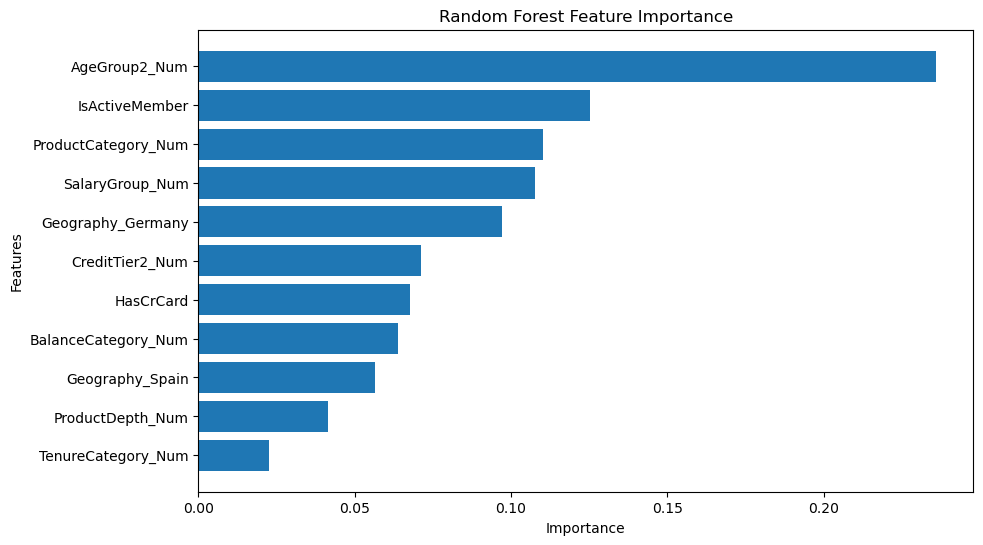

In [128]:
# Plot

plt.figure(figsize=(10,6))

plt.barh(

    feature_importance['Feature'],

    feature_importance['Importance']

)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Random Forest feature importance analysis showed that engagement-related and product utilization features contributed most strongly to churn prediction. Variables such as customer activity status, product category, salary grouping, and age segmentation emerged as major drivers of retention behavior, supporting the project objective of engagement-driven retention strategy.

## Threshold Comparison for Random Forest

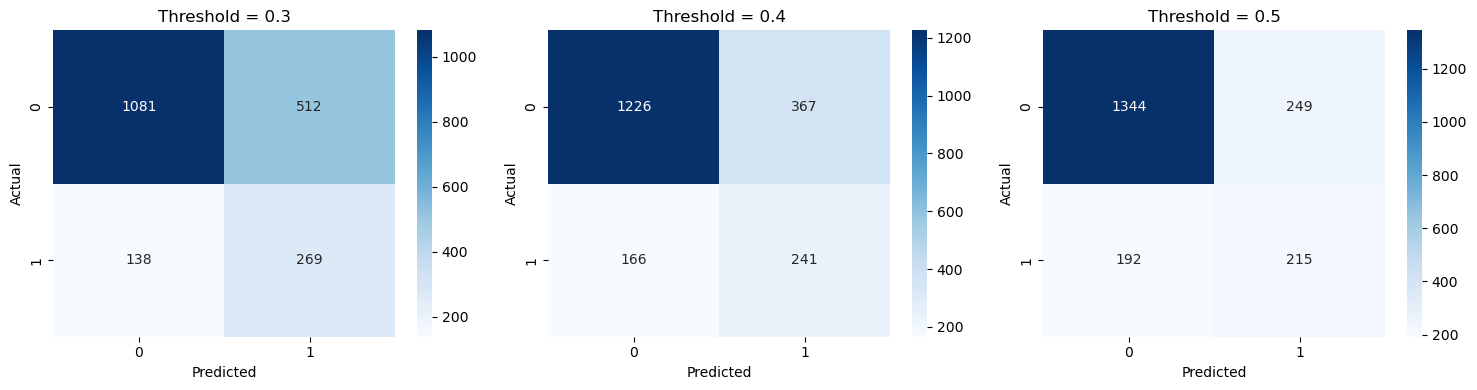

In [129]:
# Compare Confusion Matrices for Thresholds 0.3, 0.4, 0.5

# Predicted probabilities
y_prob_rf = final_model.predict_proba(X_test)[:,1]

# Thresholds
thresholds = [0.3, 0.4, 0.5]

# Plot
plt.figure(figsize=(15,4))

for i, threshold in enumerate(thresholds, 1):

    # Custom predictions
    y_pred_threshold = (y_prob_rf>= threshold).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_threshold)

    # Subplot
    plt.subplot(1, 3, i)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Threshold = {threshold}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()

plt.show()

**Threshold = 0.3**
- Recall becomes very high
- but false alarms becomes huge
- Retention team may waste resources targeting too many safe customers.
  
**Threshold = 0.4**
- good churn capture
- manageable false positives
- balanced business strategy

**Threshold = 0.5 (default)**
- Conservative predictions
- Fewer false positives
- More missed churners

**Final Selection:** Threshold = 0.4

## Precison-Recall Curve

In [ ]:
# Precision-Recall Curve with Different Thresholds

# Predicted probabilities
y_prob = final_model.predict_proba(X_test)[:,1]

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

# Plot PR Curve
plt.figure(figsize=(8,6))

plt.plot(recall, precision, label='PR Curve')

# Mark important thresholds
selected_thresholds = [0.3, 0.4, 0.5]

for threshold in selected_thresholds:

    # Find closest threshold index
    idx = (abs(thresholds - threshold)).argmin()

    plt.scatter(
        recall[idx],
        precision[idx],
        label=f'Threshold {threshold}'
    )

# Labels
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve with Thresholds")

plt.legend()

plt.show()

---

## ROC- AUC Curve

In [ ]:
# Predicted probabilities
y_prob = final_model.predict_proba(X_test)[:,1]

# ---------------- ROC Curve ---------------- #

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

# Train Final Random Forest Model on Complete Dataset

In [ ]:
# Apply SMOTE on complete dataset
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)


# Train on complete balanced data
final_model.fit(X_smote, y_smote)

print("Final model trained successfully.")

# Conclusion

This project reframes customer churn from a behavioral and relationship-strength perspective. By focusing on engagement and product utilization rather than demographics, it provides actionable insights for retention strategy design, product optimization, and customer loyalty enhancement.

                                                 

<div align="center">

###   • • • • •  

</div>
